# Selezione di biomarcatori e classificazione ALL vs AML

**Analisi dei Dati 2025/26 — Final Task**

Dataset: Golub et al. (1999), 72 pazienti, 7129 sonde geniche, due fattori diagnostici
(leucemia linfoblastica acuta, ALL, nelle varianti B e T, contro leucemia mieloide acuta, AML)
piu cinque covariate cliniche.

L'obiettivo posto dalla consegna non e massimizzare l'accuratezza, ma costruire un
insieme di biomarcatori **sparso** e **riproducibile**, documentando esplicitamente due
fenomeni statistici: l'effetto della multi-collinearita sulla sparsita, e il contrasto fra
i geni statisticamente significativi e quelli selezionati dai modelli di machine learning.

Il notebook e organizzato in cinque fasi:

1. preparazione dei dati, preprocessing dei microarray e analisi esplorativa (inclusa la
   verifica dei confonditori);
2. filtraggio statistico univariato con controllo del False Discovery Rate;
3. classificazione e selezione delle variabili tramite regolarizzazione L1;
4. stabilita della selezione tramite ricampionamento bootstrap;
5. sintesi, confronto fra metodi e conclusioni.

Ogni fase si chiude con una lettura dei risultati, non con i soli numeri.

## Fase 1 — Preparazione dei dati e analisi esplorativa

Tre questioni vanno risolte prima di qualunque modello.

**Natura dei valori.** I numeri del file non sono intensita di fluorescenza ma valori
*Average Difference* di Affymetrix MAS 4.0: medie della differenza fra sonde *perfect match*
e *mismatch*. Essendo differenze possono essere negative, e infatti lo sono nel 69% dei casi.
Non sono dati corrotti: indicano geni il cui segnale non si distingue dal rumore di fondo.

**Preprocessing.** Applichiamo la procedura usata da Dudoit, Fridlyand & Speed (2002, §3.1.2)
sul medesimo dataset. Va segnalato che quelle soglie **non compaiono nell'articolo di
Golub et al. (1999)**: gli autori di Dudoit le attribuiscono a una comunicazione personale
con P. Tamayo, coautore di Golub. Citiamo quindi Dudoit, non Golub, per questo passaggio.

**Prevenzione del leakage.** Tutto cio che stima parametri dai dati (filtro delle sonde,
standardizzazione, test statistici, selezione, tuning) viene calcolato esclusivamente sul
training set. Il test set viene toccato solo in fase di valutazione.

In [1]:
import warnings
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import RFECV, SelectFromModel
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    GridSearchCV, cross_val_score,
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
)
from sklearn.utils import resample

from matplotlib_venn import venn2, venn2_circles, venn3, venn3_circles
from mrmr import mrmr_classif
from IPython.display import display

# --- Costanti globali -------------------------------------------------------
RANDOM_STATE = 43          # seme unico: la consegna valuta la riproducibilita
N_BOOTSTRAP = 100          # repliche bootstrap per la stability selection
N_PERM = 20                # permutazioni per il null della stability selection
STABILITY_THRESHOLD = 0.80 # soglia di inclusion probability per il pannello finale
K_MRMR = 100               # feature trattenute dal filtro mRMR
FDR_ALPHA = 0.05           # livello per la correzione di Benjamini-Hochberg
FLOOR, CEIL = 100, 16000   # soglie di thresholding (Dudoit et al. 2002)

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

rng = np.random.default_rng(RANDOM_STATE)
# --- Indici di stabilita della selezione (usati nelle Fasi 4 e 5) -----------
def jaccard_index(sets):
    """Sovrapposizione media |A intersect B| / |A union B| fra coppie di repliche."""
    vals = [len(a & b) / len(a | b) for a, b in combinations(sets, 2) if a | b]
    return float(np.mean(vals)) if vals else np.nan


def kuncheva_index(sets, n_total):
    """Come Jaccard ma corretto per la sovrapposizione attesa per puro caso.
    Vale 1 per selezioni identiche e circa 0 per selezioni indipendenti."""
    vals = []
    for a, b in combinations(sets, 2):
        k = min(len(a), len(b))
        if k == 0 or k == n_total:
            continue
        expected = k * k / n_total
        if k - expected == 0:
            continue
        vals.append((len(a & b) - expected) / (k - expected))
    return float(np.mean(vals)) if vals else np.nan


def mean_inclusion(stab_df, panel):
    """Probabilita media di inclusione dei geni di un pannello."""
    m = stab_df.set_index('Gene_Probe')['Inclusion_Probability']
    return float(np.mean([m.get(g, 0.0) for g in panel])) if panel else np.nan

print("Ambiente inizializzato.")

Ambiente inizializzato.


In [2]:
raw_df = pd.read_csv("golub.csv", index_col=0)
raw_df["target"] = raw_df["cancer"].map({"allB": 0, "allT": 0, "aml": 1})

metadata_cols = ["BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"]
gene_cols_all = [c for c in raw_df.columns if c not in metadata_cols]

X_all = raw_df[gene_cols_all]
y = raw_df["target"]

print(f"Pazienti: {raw_df.shape[0]}")
print(f"Sonde geniche: {len(gene_cols_all)}")
print(f"Covariate cliniche: {[c for c in metadata_cols if c != 'target']}")
print()
print("Sottotipi originali e loro raggruppamento nel target binario:")
display(raw_df.groupby(["cancer", "target"]).size().rename("n").reset_index())
print(f"ALL (allB + allT) = {(y == 0).sum()} pazienti, AML = {(y == 1).sum()} pazienti.")
print()
print("Le due varianti allB e allT vengono unite in un'unica classe ALL, come richiesto")
print("dalla consegna. Ne risulta uno sbilanciamento di circa 2:1 che imporra l'uso di")
print("class_weight='balanced' e della balanced accuracy come metrica.")

Pazienti: 72
Sonde geniche: 7129
Covariate cliniche: ['BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer']

Sottotipi originali e loro raggruppamento nel target binario:


,cancer,target,n
0,allB,0,38
1,allT,0,9
2,aml,1,25


ALL (allB + allT) = 47 pazienti, AML = 25 pazienti.

Le due varianti allB e allT vengono unite in un'unica classe ALL, come richiesto
dalla consegna. Ne risulta uno sbilanciamento di circa 2:1 che imporra l'uso di
class_weight='balanced' e della balanced accuracy come metrica.


--- Natura dei valori di espressione ---
minimo -62,719   massimo 139,396   mediana -433
frazione di valori negativi: 69.0%
percentili 1/25/50/75/99: -2,888 | -786 | -433 | 241 | 31,187
sonde con massimo < 100 su tutti i 72 pazienti: 2461

Lettura: la distribuzione e fortemente asimmetrica (dal 75esimo al 99esimo percentile
si passa da poche centinaia a decine di migliaia) e circa un terzo delle sonde non si
accende mai in nessun paziente: sono rumore strumentale puro. Entrambe le cose
motivano il preprocessing della cella successiva.


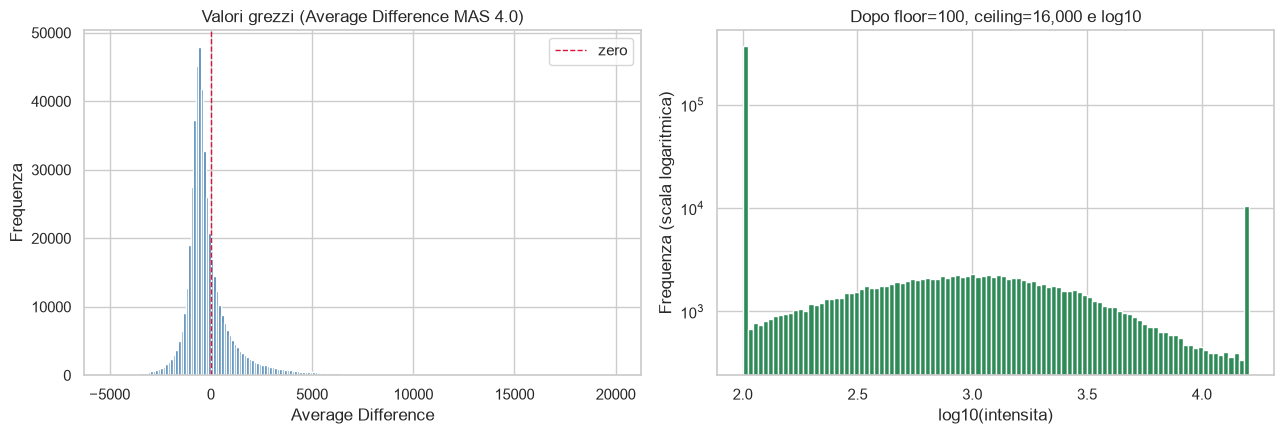


Il pannello di destra usa l'asse y logaritmico: senza di esso il picco al floor
(72% dei valori) schiaccerebbe contro l'asse x tutto il resto. Si
distinguono cosi tre popolazioni: il rumore compresso al floor, i valori informativi
(26%, distribuiti fra log10=2 e log10=4.2) e la saturazione al ceiling
(2%). Il filtro della cella successiva elimina la prima popolazione.


In [3]:
G = X_all.to_numpy(dtype=float)

print("--- Natura dei valori di espressione ---")
print(f"minimo {G.min():,.0f}   massimo {G.max():,.0f}   mediana {np.median(G):,.0f}")
print(f"frazione di valori negativi: {(G < 0).mean():.1%}")
qs = np.percentile(G, [1, 25, 50, 75, 99])
print("percentili 1/25/50/75/99: " + " | ".join(f"{q:,.0f}" for q in qs))
print(f"sonde con massimo < {FLOOR} su tutti i {G.shape[0]} pazienti: {(G.max(axis=0) < FLOOR).sum()}")
print()
print("Lettura: la distribuzione e fortemente asimmetrica (dal 75esimo al 99esimo percentile")
print("si passa da poche centinaia a decine di migliaia) e circa un terzo delle sonde non si")
print("accende mai in nessun paziente: sono rumore strumentale puro. Entrambe le cose")
print("motivano il preprocessing della cella successiva.")

G_clip = np.log10(np.clip(G, FLOOR, CEIL)).ravel()
at_floor = (G_clip == np.log10(FLOOR)).mean()
at_ceil = (G_clip == np.log10(CEIL)).mean()
interior = 1 - at_floor - at_ceil

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(G.ravel(), bins=200, range=(-5000, 20000), color="steelblue")
axes[0].set_title("Valori grezzi (Average Difference MAS 4.0)")
axes[0].set_xlabel("Average Difference")
axes[0].set_ylabel("Frequenza")
axes[0].axvline(0, color="crimson", linestyle="--", linewidth=1, label="zero")
axes[0].legend()

axes[1].hist(G_clip, bins=100, color="seagreen")
axes[1].set_yscale("log")
axes[1].set_title(f"Dopo floor={FLOOR}, ceiling={CEIL:,} e log10")
axes[1].set_xlabel("log10(intensita)")
axes[1].set_ylabel("Frequenza (scala logaritmica)")
plt.tight_layout()
plt.show()

print()
print("Il pannello di destra usa l'asse y logaritmico: senza di esso il picco al floor")
print(f"({at_floor:.0%} dei valori) schiaccerebbe contro l'asse x tutto il resto. Si")
print("distinguono cosi tre popolazioni: il rumore compresso al floor, i valori informativi")
print(f"({interior:.0%}, distribuiti fra log10=2 e log10=4.2) e la saturazione al ceiling")
print(f"({at_ceil:.0%}). Il filtro della cella successiva elimina la prima popolazione.")


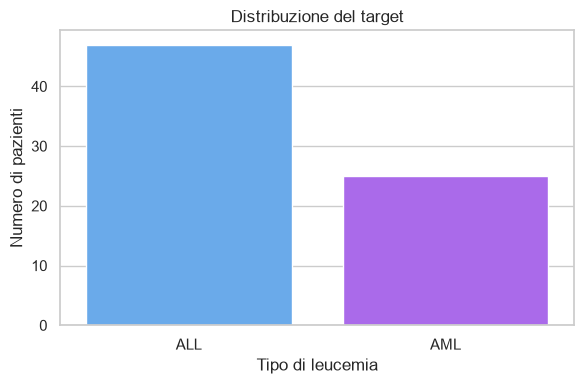

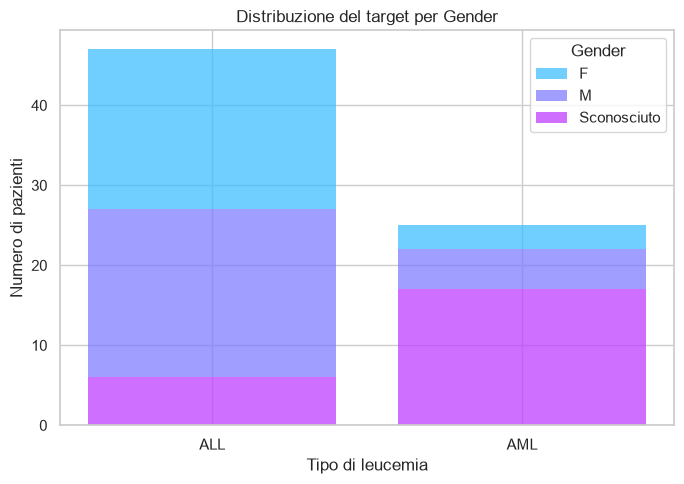

In [4]:
def plot_target_distribution(y_vec, title="Distribuzione del target"):
    plt.figure(figsize=(6, 4))
    lab = y_vec.map({0: "ALL", 1: "AML"})
    sns.countplot(x=lab, hue=lab, palette="cool", legend=False)
    plt.xlabel("Tipo di leucemia")
    plt.ylabel("Numero di pazienti")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_target_stacked(y_vec, stacks, hue_label):
    plot_df = pd.DataFrame({
        "target_label": y_vec.map({0: "ALL", 1: "AML"}).to_numpy(),
        hue_label: pd.Series(stacks).fillna("Sconosciuto").to_numpy(),
    })
    plt.figure(figsize=(7, 5))
    ax = sns.histplot(data=plot_df, x="target_label", hue=hue_label,
                      multiple="stack", shrink=0.8, palette="cool",
                      edgecolor="none", linewidth=0)
    ax.set_xlabel("Tipo di leucemia")
    ax.set_ylabel("Numero di pazienti")
    ax.set_title(f"Distribuzione del target per {hue_label}")
    plt.tight_layout()
    plt.show()


plot_target_distribution(y)
plot_target_stacked(y, raw_df["Gender"], "Gender")

### 1.1 Controllo dei confonditori

Le cinque covariate cliniche non entrano nella matrice delle feature, ma escluderle senza
verificarle sarebbe un errore: se una di esse fosse associata alla diagnosi, i geni
selezionati potrebbero riflettere un effetto tecnico invece che biologico. La verifica e
particolarmente necessaria per `Source`, il centro di raccolta, che nei dati di espressione
genica e il confonditore di batch classico (protocollo di laboratorio, lotto di chip,
operatore).

In [5]:
rows = []
for col in ["BM.PB", "Gender", "Source", "tissue.mf"]:
    tab = pd.crosstab(raw_df[col], y.map({0: "ALL", 1: "AML"}))
    chi2, p, dof, _ = chi2_contingency(tab)
    rows.append({"Fattore": col, "chi2": round(chi2, 2), "dof": dof,
                 "p_value": f"{p:.3g}", "Associato al target": "SI" if p < 0.05 else "no"})
    print(f"--- {col} contro la diagnosi ---")
    display(tab)

confound_table = pd.DataFrame(rows)
print("--- Test di associazione (chi-quadro) ---")
display(confound_table)

--- BM.PB contro la diagnosi ---


target,ALL,AML
BM.PB,,
BM,41,21
PB,6,4


--- Gender contro la diagnosi ---


target,ALL,AML
Gender,,
F,20,3
M,21,5


--- Source contro la diagnosi ---


target,ALL,AML
Source,,
CALGB,0,15
CCG,0,5
DFCI,44,0
St-Jude,3,5


--- tissue.mf contro la diagnosi ---


target,ALL,AML
tissue.mf,,
BM:NA,4,16
BM:f,19,2
BM:m,18,3
PB:NA,2,1
PB:f,1,1
PB:m,3,2


--- Test di associazione (chi-quadro) ---


,Fattore,chi2,dof,p_value,Associato al target
0,BM.PB,0.00,1,0.984,no
1,Gender,0.04,1,0.843,no
2,Source,63.73,3,9.39e-14,SI
3,tissue.mf,28.11,5,3.46e-05,SI


Il risultato su `Source` e severo e va dichiarato apertamente.

I quattro centri contribuiscono in modo quasi perfettamente separato per classe: DFCI
fornisce 44 pazienti ALL e nessun AML, CALGB 15 AML e nessun ALL, CCG 5 AML e nessun ALL;
solo St-Jude e misto (3 ALL, 5 AML). In totale **64 pazienti su 72 provengono da centri che
hanno contribuito una sola classe**.

La conseguenza e strutturale, non rimediabile con tecniche statistiche: qualunque effetto
tecnico specifico del laboratorio e **matematicamente indistinguibile** dal segnale
biologico ALL contro AML, perche le due variabili sono quasi collineari. Nessun modello, per
quanto ben regolarizzato, puo separare le due componenti a partire da questi dati.

Non includiamo le covariate come regressori proprio per questa ragione: essendo predittori
quasi perfetti del target, mascherebbero il segnale genico invece di correggerlo. La scelta
corretta e usarle come strumento diagnostico — cosa che facciamo qui e di nuovo dopo la
PCA e dopo la selezione finale — e dichiarare il limite nell'interpretazione dei risultati.
Questo e un difetto di design dello studio originale del 1999, non della presente analisi.

In [6]:
X_thr = X_all.clip(lower=FLOOR, upper=CEIL)

X_train_int, X_test_int, y_train, y_test = train_test_split(
    X_thr, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

mx, mn = X_train_int.max(axis=0), X_train_int.min(axis=0)
probe_mask = ~((mx / mn <= 5) | ((mx - mn) <= 500))
feature_cols = list(X_train_int.columns[probe_mask])

X_train_log = np.log10(X_train_int.loc[:, probe_mask])
X_test_log = np.log10(X_test_int.loc[:, probe_mask])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_log)
X_test = scaler.transform(X_test_log)

print("--- Preprocessing (Dudoit et al. 2002, §3.1.2) ---")
print(f"(a) thresholding: floor {FLOOR}, ceiling {CEIL:,}")
print(f"(b) filtro: esclusi i probe con max/min <= 5 OPPURE (max - min) <= 500")
print(f"(c) trasformazione log10")
print()
print(f"Sonde iniziali:   {X_all.shape[1]}")
print(f"Sonde superstiti: {len(feature_cols)}")
print(f"Sonde eliminate:  {X_all.shape[1] - len(feature_cols)} "
      f"({1 - len(feature_cols)/X_all.shape[1]:.0%})")
print()
print(f"Training set: {X_train.shape[0]} pazienti "
      f"({(y_train == 0).sum()} ALL / {(y_train == 1).sum()} AML)")
print(f"Test set:     {X_test.shape[0]} pazienti "
      f"({(y_test == 0).sum()} ALL / {(y_test == 1).sum()} AML)")

assert X_train.shape[1] == len(feature_cols) == X_test.shape[1]
assert np.isfinite(X_train).all() and np.isfinite(X_test).all()

--- Preprocessing (Dudoit et al. 2002, §3.1.2) ---
(a) thresholding: floor 100, ceiling 16,000
(b) filtro: esclusi i probe con max/min <= 5 OPPURE (max - min) <= 500
(c) trasformazione log10

Sonde iniziali:   7129
Sonde superstiti: 3363
Sonde eliminate:  3766 (53%)

Training set: 57 pazienti (37 ALL / 20 AML)
Test set:     15 pazienti (10 ALL / 5 AML)


Tre precisazioni metodologiche su questo passaggio.

**L'ordine e vincolante:** floor/ceiling, poi filtro, poi logaritmo. Il flooring deve
precedere il filtro perche il rapporto `max/min` su valori negativi non ha significato, e
deve precedere il logaritmo perche il logaritmo di un numero negativo non esiste. La stessa
operazione risolve due problemi distinti.

**Il criterio e un OR con `<=`**, non un AND: basta violare una delle due condizioni per
essere esclusi. La differenza non e cosmetica — con l'AND sopravviverebbero circa 360 sonde
in piu, che entrerebbero nel pool dei test multipli e della selezione.

**Il filtro e stimato sul solo training set.** Dudoit lo calcolava su tutti e 72 i campioni;
essendo un filtro non supervisionato — non guarda mai `y` — la loro scelta era difendibile,
ma adottiamo la variante conservativa per coerenza con il resto della pipeline. Floor,
ceiling e logaritmo sono invece trasformazioni puntuali che non stimano nulla dai dati, e
possono essere applicate ovunque senza rischio.

Si noti infine che `StandardScaler` da solo non avrebbe risolto il problema: e una z-score
*per gene*, cioe una trasformazione affine che lascia intatte asimmetria e outlier, e che
anzi *amplifica* le sonde di puro rumore dividendole per la loro deviazione standard
minuscola. Il preprocessing agisce sulla forma della distribuzione e sul rapporto
segnale/rumore; lo scaling agisce sulle unita di misura. Servono entrambi.

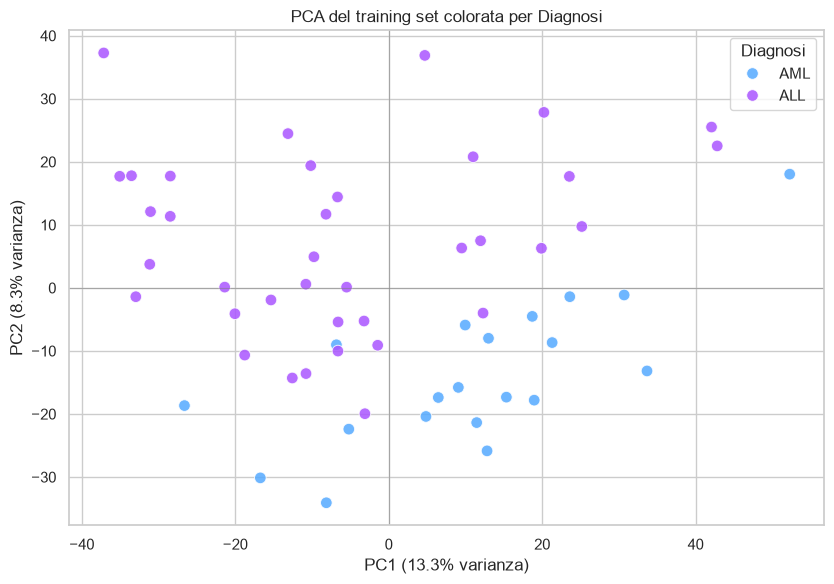

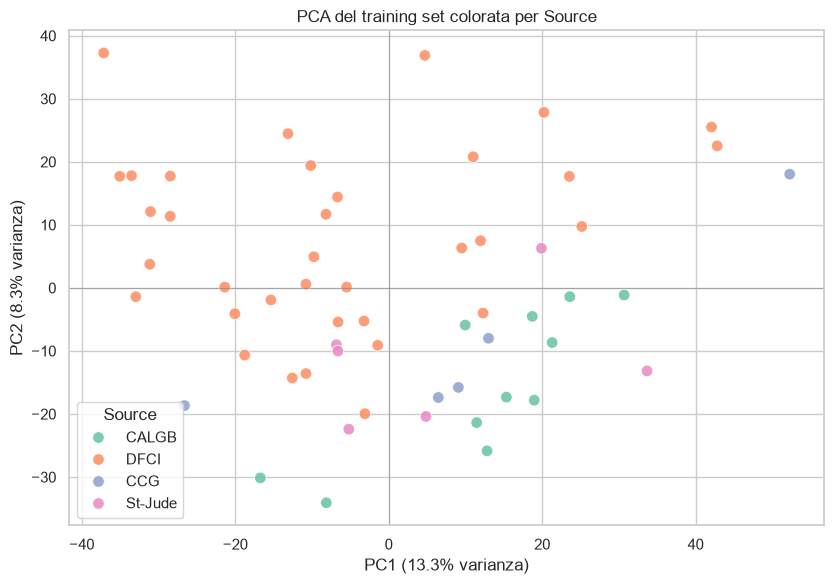

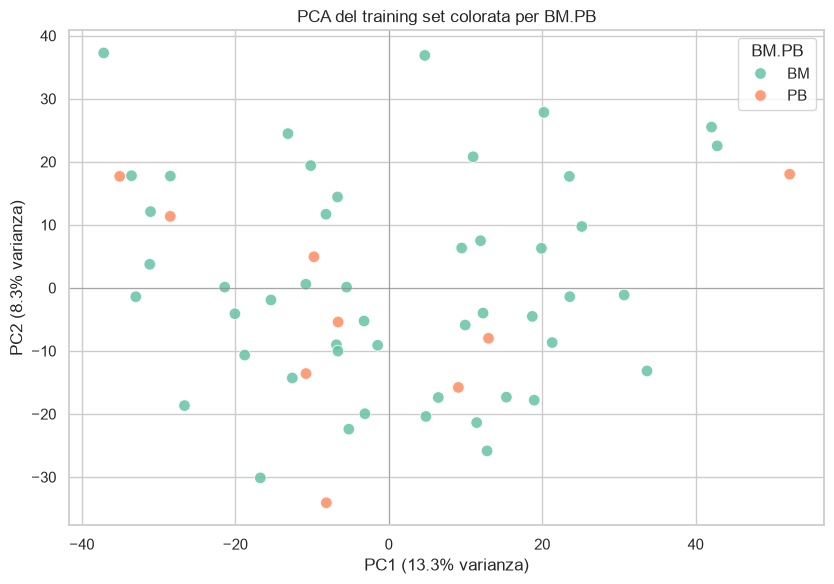

Le prime due componenti spiegano il 21.6% della varianza totale.

I tre grafici vanno letti insieme. Il primo mostra che ALL e AML si separano gia in
due dimensioni, il che e incoraggiante ma non sorprendente con p >> n. Il secondo e
il piu importante: se la separazione per Source ricalca quella per diagnosi, cio
conferma visivamente il confondimento misurato con il chi-quadro, e impone cautela
nell'attribuire significato biologico alla direzione principale di variazione.


In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
explained = pca.explained_variance_ratio_ * 100


def pca_scatter(labels, name, palette="cool"):
    plot_df = pd.DataFrame({"PC1": X_train_pca[:, 0], "PC2": X_train_pca[:, 1],
                            name: np.asarray(labels)})
    plt.figure(figsize=(8.5, 6))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue=name,
                    palette=palette, alpha=0.85, s=70)
    plt.xlabel(f"PC1 ({explained[0]:.1f}% varianza)")
    plt.ylabel(f"PC2 ({explained[1]:.1f}% varianza)")
    plt.title(f"PCA del training set colorata per {name}")
    plt.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
    plt.axvline(0, color="gray", linewidth=0.8, alpha=0.5)
    plt.tight_layout()
    plt.show()


pca_scatter(y_train.map({0: "ALL", 1: "AML"}).to_numpy(), "Diagnosi")
pca_scatter(raw_df.loc[y_train.index, "Source"].to_numpy(), "Source", palette="Set2")
pca_scatter(raw_df.loc[y_train.index, "BM.PB"].to_numpy(), "BM.PB", palette="Set2")

print(f"Le prime due componenti spiegano il {explained.sum():.1f}% della varianza totale.")
print()
print("I tre grafici vanno letti insieme. Il primo mostra che ALL e AML si separano gia in")
print("due dimensioni, il che e incoraggiante ma non sorprendente con p >> n. Il secondo e")
print("il piu importante: se la separazione per Source ricalca quella per diagnosi, cio")
print("conferma visivamente il confondimento misurato con il chi-quadro, e impone cautela")
print("nell'attribuire significato biologico alla direzione principale di variazione.")

## Fase 2 — Significativita statistica e controllo delle false scoperte

Eseguiamo un test univariato per ciascuna sonda superstite. Ne usiamo **due** anziche uno,
per ragioni che discendono direttamente dalla natura dei dati:

- il **t-test di Welch** (`equal_var=False`, non assumiamo varianze uguali fra i due gruppi)
  e efficiente ma sensibile all'asimmetria residua della distribuzione;
- il **test di Mann-Whitney U**, non parametrico, e insensibile alla forma della
  distribuzione e quindi robusto rispetto agli outlier che il preprocessing non ha rimosso.

Il baseline che porteremo avanti e l'**intersezione** dei due, cioe i geni su cui entrambi
gli approcci concordano. Con 7129 sonde di partenza, la correzione per test multipli non e
opzionale: usiamo Benjamini-Hochberg, che controlla la proporzione attesa di falsi positivi
fra i rigetti (il False Discovery Rate) invece del piu conservativo family-wise error rate.

In [8]:
X_tr_ALL = X_train[y_train.to_numpy() == 0]
X_tr_AML = X_train[y_train.to_numpy() == 1]

t_stats, p_t = ttest_ind(X_tr_ALL, X_tr_AML, equal_var=False, axis=0)
reject_t, p_t_fdr, _, _ = multipletests(p_t, alpha=FDR_ALPHA, method="fdr_bh")

p_mw = np.array([
    mannwhitneyu(X_tr_ALL[:, i], X_tr_AML[:, i], alternative="two-sided").pvalue
    for i in range(X_train.shape[1])
])
reject_mw, p_mw_fdr, _, _ = multipletests(p_mw, alpha=FDR_ALPHA, method="fdr_bh")

sig_genes_t = {feature_cols[i] for i in np.where(reject_t)[0]}
sig_genes_mw = {feature_cols[i] for i in np.where(reject_mw)[0]}
robust_baseline_genes = sig_genes_t & sig_genes_mw

significance_results = pd.DataFrame({
    "Gene_Probe": feature_cols,
    "T_Statistic": t_stats,
    "T_Test_Raw_P": p_t,
    "T_Test_FDR_P": p_t_fdr,
    "MW_Raw_P": p_mw,
    "MW_FDR_P": p_mw_fdr,
    "Sig_in_Both": [g in robust_baseline_genes for g in feature_cols],
}).sort_values("T_Test_FDR_P")

expected_false = FDR_ALPHA * len(sig_genes_t)

print("--- Filtraggio statistico univariato (FDR di Benjamini-Hochberg al 5%) ---")
print(f"Sonde testate: {len(feature_cols)}")
print(f"Significative al t-test di Welch:      {len(sig_genes_t)}")
print(f"Significative al Mann-Whitney U:       {len(sig_genes_mw)}")
print(f"Significative a ENTRAMBI (baseline):   {len(robust_baseline_genes)}")
print()
print(f"Interpretazione del controllo delle false scoperte: a FDR {FDR_ALPHA:.0%} con")
print(f"{len(sig_genes_t)} rigetti, ci si attendono circa {expected_false:.0f} falsi positivi")
print("fra i geni dichiarati significativi dal solo t-test. L'intersezione con il test non")
print("parametrico e un filtro aggiuntivo che riduce ulteriormente questo numero, al costo")
print("di una perdita di potenza. Nessuno dei due criteri, pero, dice nulla sulla")
print("RIPRODUCIBILITA della selezione: quella e la questione della Fase 4.")
print()
print("I 15 geni piu significativi:")
display(significance_results.head(15))

--- Filtraggio statistico univariato (FDR di Benjamini-Hochberg al 5%) ---
Sonde testate: 3363
Significative al t-test di Welch:      615
Significative al Mann-Whitney U:       655
Significative a ENTRAMBI (baseline):   552

Interpretazione del controllo delle false scoperte: a FDR 5% con
615 rigetti, ci si attendono circa 31 falsi positivi
fra i geni dichiarati significativi dal solo t-test. L'intersezione con il test non
parametrico e un filtro aggiuntivo che riduce ulteriormente questo numero, al costo
di una perdita di potenza. Nessuno dei due criteri, pero, dice nulla sulla
RIPRODUCIBILITA della selezione: quella e la questione della Fase 4.

I 15 geni piu significativi:


,Gene_Probe,T_Statistic,T_Test_Raw_P,T_Test_FDR_P,MW_Raw_P,MW_FDR_P,Sig_in_Both
930,M27891_at,-18.406553,4.365253e-20,1.468034e-16,3.301483e-11,1.110289e-07,True
2357,X95735_at,-14.052533,3.801624e-19,6.392430e-16,6.957796e-10,4.679814e-07,True
3246,M31523_at,13.109517,2.288727e-18,1.924247e-15,3.260736e-09,1.370732e-06,True
834,M11722_at,14.665775,1.724316e-18,1.924247e-15,7.719961e-09,2.596223e-06,True
2877,L09209_s_at,-12.162067,3.212605e-17,2.160798e-14,3.933132e-09,1.469680e-06,True
941,M29696_at,9.015588,2.530335e-12,1.418253e-09,7.193605e-08,1.344005e-05,True
2113,X61587_at,-9.353645,4.978780e-12,2.346374e-09,1.580236e-08,4.831213e-06,True
598,J05243_at,9.903443,5.581621e-12,2.346374e-09,3.963145e-08,8.330035e-06,True
2123,X62654_rna1_at,-8.739726,6.287393e-12,2.349389e-09,2.410725e-08,5.790906e-06,True
865,M16038_at,-9.788521,1.131814e-11,3.806289e-09,3.252315e-09,1.370732e-06,True


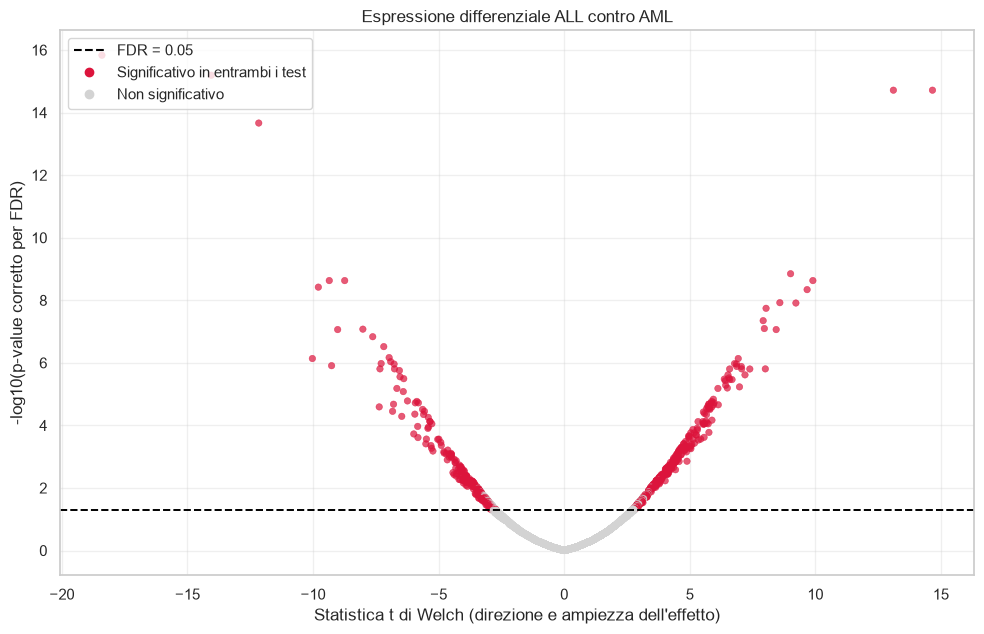

Nota sulla lettura: l'asse orizzontale riporta la statistica t, non un log fold
change come in un volcano plot canonico. La t incorpora gia la variabilita entro
gruppo, quindi la larghezza del grafico va letta come rapporto segnale/rumore e non
come ampiezza biologica dell'effetto.


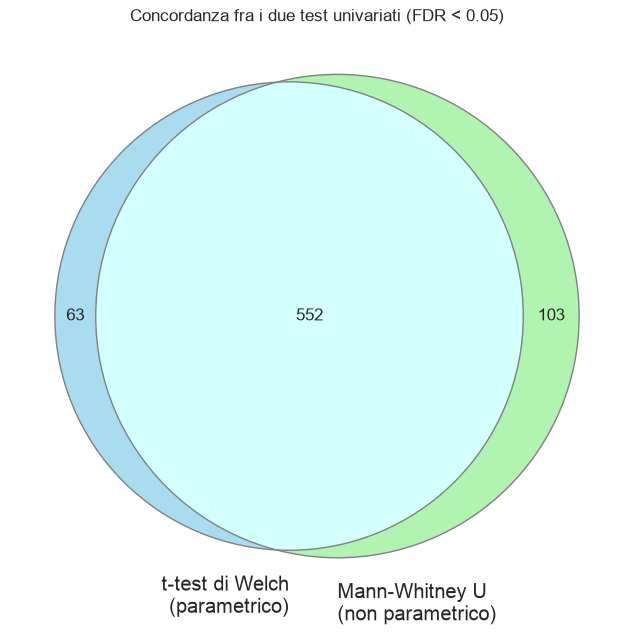

In [9]:
volcano_df = significance_results.copy()
volcano_df["neg_log10_FDR"] = -np.log10(volcano_df["T_Test_FDR_P"] + 1e-300)

plt.figure(figsize=(10, 6.5))
sns.scatterplot(data=volcano_df, x="T_Statistic", y="neg_log10_FDR",
                hue="Sig_in_Both", palette={False: "lightgray", True: "crimson"},
                alpha=0.7, edgecolor=None, s=22, legend=False)
plt.axhline(-np.log10(FDR_ALPHA), color="black", linestyle="--", linewidth=1.4)
plt.title("Espressione differenziale ALL contro AML")
plt.xlabel("Statistica t di Welch (direzione e ampiezza dell'effetto)")
plt.ylabel("-log10(p-value corretto per FDR)")
plt.legend(handles=[
    mlines.Line2D([], [], color="black", linestyle="--", label=f"FDR = {FDR_ALPHA}"),
    mlines.Line2D([], [], marker="o", color="crimson", linestyle="", label="Significativo in entrambi i test"),
    mlines.Line2D([], [], marker="o", color="lightgray", linestyle="", label="Non significativo"),
], loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Nota sulla lettura: l'asse orizzontale riporta la statistica t, non un log fold")
print("change come in un volcano plot canonico. La t incorpora gia la variabilita entro")
print("gruppo, quindi la larghezza del grafico va letta come rapporto segnale/rumore e non")
print("come ampiezza biologica dell'effetto.")

plt.figure(figsize=(6.5, 6.5))
subsets = (len(sig_genes_t - sig_genes_mw), len(sig_genes_mw - sig_genes_t),
           len(robust_baseline_genes))
venn2(subsets=subsets, set_labels=("t-test di Welch\n(parametrico)",
                                   "Mann-Whitney U\n(non parametrico)"),
      set_colors=("skyblue", "lightgreen"), alpha=0.7)
venn2_circles(subsets=subsets, linestyle="solid", linewidth=1.0, color="gray")
plt.title(f"Concordanza fra i due test univariati (FDR < {FDR_ALPHA})")
plt.tight_layout()
plt.show()

## Fase 3 — Classificazione e selezione delle variabili

Con p >> n (migliaia di sonde contro 57 pazienti di training) la regressione logistica non
regolarizzata e indeterminata: esistono infiniti separatori perfetti. La penalita **L1**
risolve simultaneamente due problemi — rende il problema ben posto e produce una soluzione
**sparsa**, azzerando esattamente i coefficienti dei geni non informativi. E questa proprieta
di sparsita esatta a rendere l'L1 lo strumento naturale per la selezione di biomarcatori.

**Nota sull'API di scikit-learn.** Dalla versione 1.8 il parametro `penalty` e deprecato e
sara rimosso nella 1.10: il tipo di penalizzazione si specifica ora tramite `l1_ratio`
(`1.0` = L1 puro, `0.0` = L2 puro, valori intermedi = elastic net). Usiamo la nuova API in
tutto il notebook.

**Nota sul solver.** Usiamo `liblinear` per l'L1 puro. La scelta non e cosmetica: su questi
dati `saga` con `max_iter=10000` **non raggiunge la convergenza**, e un modello non
convergente riporta molti piu coefficienti non nulli di quelli della soluzione vera,
gonfiando artificialmente il conteggio dei geni selezionati. A convergenza i due solver
concordano, ma `liblinear` e alcuni ordini di grandezza piu veloce, il che rende praticabili
le migliaia di fit richiesti dalla stability selection e dal test di permutazione.

In [10]:
param_grid = {"C": np.logspace(-3, 1, 30)}

lasso_model = LogisticRegression(
    l1_ratio=1.0, solver="liblinear", class_weight="balanced",
    max_iter=5000, tol=1e-8, random_state=RANDOM_STATE,
)
lasso_grid = GridSearchCV(
    estimator=lasso_model,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="balanced_accuracy",
    n_jobs=-1,
)
lasso_grid.fit(X_train, y_train)

lasso_best = lasso_grid.best_estimator_
lasso_optimal_C = lasso_grid.best_params_["C"]
lasso_coefs = lasso_best.coef_[0]
selected_indices = np.where(lasso_coefs != 0)[0]
selected_genes_lasso = [feature_cols[i] for i in selected_indices]

print("--- Regressione logistica L1: ricerca del parametro di regolarizzazione ---")
print(f"Griglia esplorata: C da {param_grid['C'][0]:.4f} a {param_grid['C'][-1]:.4f} (30 valori log-spaziati)")
print(f"C ottimale: {lasso_optimal_C:.4f}")
print(f"Balanced accuracy in cross-validation: {lasso_grid.best_score_:.3f}")
print(f"Geni con coefficiente non nullo: {len(selected_genes_lasso)} su {len(feature_cols)}")
print(f"Sparsita: {1 - len(selected_genes_lasso)/len(feature_cols):.2%} delle sonde azzerate")

if lasso_optimal_C in (param_grid["C"][0], param_grid["C"][-1]):
    print("\nATTENZIONE: l'ottimo cade sul bordo della griglia. L'intervallo di C va allargato.")
else:
    print("\nL'ottimo cade all'interno della griglia: l'intervallo esplorato e adeguato.")

importance_df = pd.DataFrame({
    "Gene_Probe": selected_genes_lasso,
    "Coefficient": lasso_coefs[selected_indices],
    "Absolute_Weight": np.abs(lasso_coefs[selected_indices]),
}).sort_values("Absolute_Weight", ascending=False)
print("\nGeni con il peso maggiore:")
display(importance_df.head(10))

--- Regressione logistica L1: ricerca del parametro di regolarizzazione ---
Griglia esplorata: C da 0.0010 a 10.0000 (30 valori log-spaziati)
C ottimale: 2.8072
Balanced accuracy in cross-validation: 1.000
Geni con coefficiente non nullo: 16 su 3363
Sparsita: 99.52% delle sonde azzerate

L'ottimo cade all'interno della griglia: l'intervallo esplorato e adeguato.

Geni con il peso maggiore:


,Gene_Probe,Coefficient,Absolute_Weight
7,M27891_at,2.487983,2.487983
9,X95735_at,1.015511,1.015511
2,D88422_at,0.536460,0.536460
5,L05148_at,-0.482300,0.482300
6,M11722_at,-0.372874,0.372874
12,U59632_s_at,0.259878,0.259878
4,J05243_at,-0.220127,0.220127
11,L09209_s_at,0.155958,0.155958
0,D26308_at,0.140871,0.140871
13,M13690_s_at,0.135702,0.135702


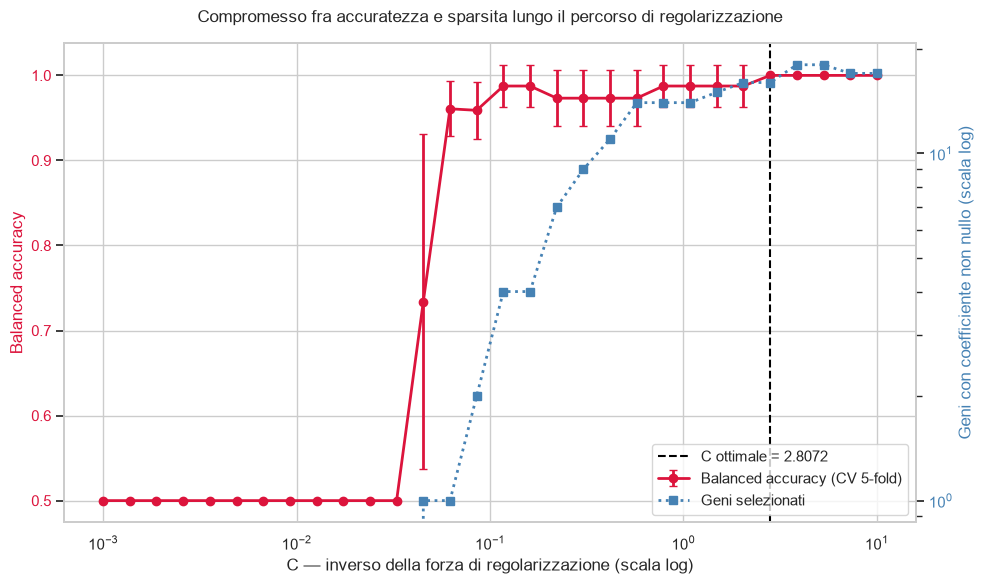

Al C ottimale il modello usa 16 geni con balanced accuracy 1.000.

Questa curva e la risposta diretta al criterio di 'sparsita' della consegna: mostra
che l'accuratezza raggiunge un plateau molto prima che il numero di geni smetta di
crescere. Aumentare C oltre l'ottimo compra quindi complessita senza comprare
accuratezza — ed e esattamente la regione in cui la selezione diventa instabile,
come verifichiamo nella fase successiva.


In [11]:
cv_scores = lasso_grid.cv_results_["mean_test_score"]
cv_std = lasso_grid.cv_results_["std_test_score"]
C_grid = param_grid["C"]

n_selected = []
for c in C_grid:
    m = LogisticRegression(l1_ratio=1.0, solver="liblinear", C=c,
                           class_weight="balanced", max_iter=5000, tol=1e-8,
                           random_state=RANDOM_STATE).fit(X_train, y_train)
    n_selected.append(int((m.coef_[0] != 0).sum()))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.errorbar(C_grid, cv_scores, yerr=cv_std, color="crimson", marker="o",
             capsize=3, linewidth=2, label="Balanced accuracy (CV 5-fold)")
ax1.set_xscale("log")
ax1.set_xlabel("C — inverso della forza di regolarizzazione (scala log)")
ax1.set_ylabel("Balanced accuracy", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")
ax1.axvline(lasso_optimal_C, color="black", linestyle="--",
            label=f"C ottimale = {lasso_optimal_C:.4f}")

ax2 = ax1.twinx()
ax2.plot(C_grid, n_selected, color="steelblue", marker="s", linestyle=":",
         linewidth=2, label="Geni selezionati")
ax2.set_yscale("log")
ax2.set_ylabel("Geni con coefficiente non nullo (scala log)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.grid(False)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower right")
plt.title("Compromesso fra accuratezza e sparsita lungo il percorso di regolarizzazione", pad=15)
plt.tight_layout()
plt.show()

idx_opt = int(np.argmin(np.abs(C_grid - lasso_optimal_C)))
plateau = [n for c, n in zip(C_grid, cv_scores) if n >= cv_scores.max() - 0.01]
print(f"Al C ottimale il modello usa {n_selected[idx_opt]} geni con balanced accuracy "
      f"{cv_scores[idx_opt]:.3f}.")
print()
print("Questa curva e la risposta diretta al criterio di 'sparsita' della consegna: mostra")
print("che l'accuratezza raggiunge un plateau molto prima che il numero di geni smetta di")
print("crescere. Aumentare C oltre l'ottimo compra quindi complessita senza comprare")
print("accuratezza — ed e esattamente la regione in cui la selezione diventa instabile,")
print("come verifichiamo nella fase successiva.")

## Fase 4 — Stabilita della selezione (requisito centrale della consegna)

Un singolo fit su un singolo campione produce **una** lista di geni. Nulla garantisce che
quella lista si riproduca su un campione diverso: con p >> n e feature correlate, piccole
perturbazioni dei dati possono cambiare radicalmente l'insieme selezionato pur lasciando
invariata l'accuratezza. E precisamente il fenomeno che la consegna chiede di documentare.

La **stability selection** misura questo direttamente: si ricampionano i pazienti con
ripetizione, si **rifa la selezione da capo** su ciascuna replica, e si conta con quale
frequenza ciascun gene viene scelto. La frequenza empirica e la *inclusion probability*, e
il pannello finale e composto dai geni che superano una soglia — qui l'80%.

Due dettagli che rendono la stima corretta: il ricampionamento e **stratificato**, per
evitare che repliche con proporzioni di classe anomale aggiungano rumore alle probabilita;
e la selezione viene **rieseguita interamente dentro ogni replica**, non riutilizzata da un
fit globale (che sarebbe una forma di leakage e produrrebbe stabilita fittizia).

In [12]:
boot_lasso = LogisticRegression(
    l1_ratio=1.0, solver="liblinear", C=lasso_optimal_C,
    class_weight="balanced", max_iter=5000, tol=1e-8, random_state=RANDOM_STATE,
)

lasso_boot_sets = []
counts = Counter()

for i in range(N_BOOTSTRAP):
    X_boot, y_boot = resample(X_train, y_train, random_state=i, stratify=y_train)
    boot_lasso.fit(X_boot, y_boot)
    idx = np.where(boot_lasso.coef_[0] != 0)[0]
    genes = {feature_cols[j] for j in idx}
    lasso_boot_sets.append(genes)
    counts.update(genes)

lasso_stability_df = (
    pd.DataFrame({"Gene_Probe": list(counts.keys()),
                  "Selection_Count": list(counts.values())})
    .assign(Inclusion_Probability=lambda d: d["Selection_Count"] / N_BOOTSTRAP)
    .sort_values("Inclusion_Probability", ascending=False)
    .reset_index(drop=True)
)

lasso_stable_df = lasso_stability_df[
    lasso_stability_df["Inclusion_Probability"] >= STABILITY_THRESHOLD
]
lasso_final_genes = lasso_stable_df["Gene_Probe"].tolist()
lasso_stable_set = set(lasso_final_genes)

print(f"--- Stability selection su {N_BOOTSTRAP} repliche bootstrap stratificate ---")
print(f"Geni selezionati almeno una volta: {len(lasso_stability_df)}")
print(f"Geni con inclusion probability >= {STABILITY_THRESHOLD:.0%}: {len(lasso_final_genes)}")
print(f"Dimensione media della selezione per replica: "
      f"{np.mean([len(s) for s in lasso_boot_sets]):.1f} geni")
print()
print("Il contrasto fra questi numeri e gia di per se il risultato: molte centinaia di geni")
print("vengono scelti almeno una volta, ma pochissimi lo sono in modo sistematico. La")
print("differenza fra i due conteggi misura quanto la selezione sia sensibile al campione.")
print()
print("Pannello finale:")
display(lasso_stable_df.reset_index(drop=True))

--- Stability selection su 100 repliche bootstrap stratificate ---
Geni selezionati almeno una volta: 282
Geni con inclusion probability >= 80%: 2
Dimensione media della selezione per replica: 14.3 geni

Il contrasto fra questi numeri e gia di per se il risultato: molte centinaia di geni
vengono scelti almeno una volta, ma pochissimi lo sono in modo sistematico. La
differenza fra i due conteggi misura quanto la selezione sia sensibile al campione.

Pannello finale:


,Gene_Probe,Selection_Count,Inclusion_Probability
0,M27891_at,97,0.97
1,X95735_at,86,0.86


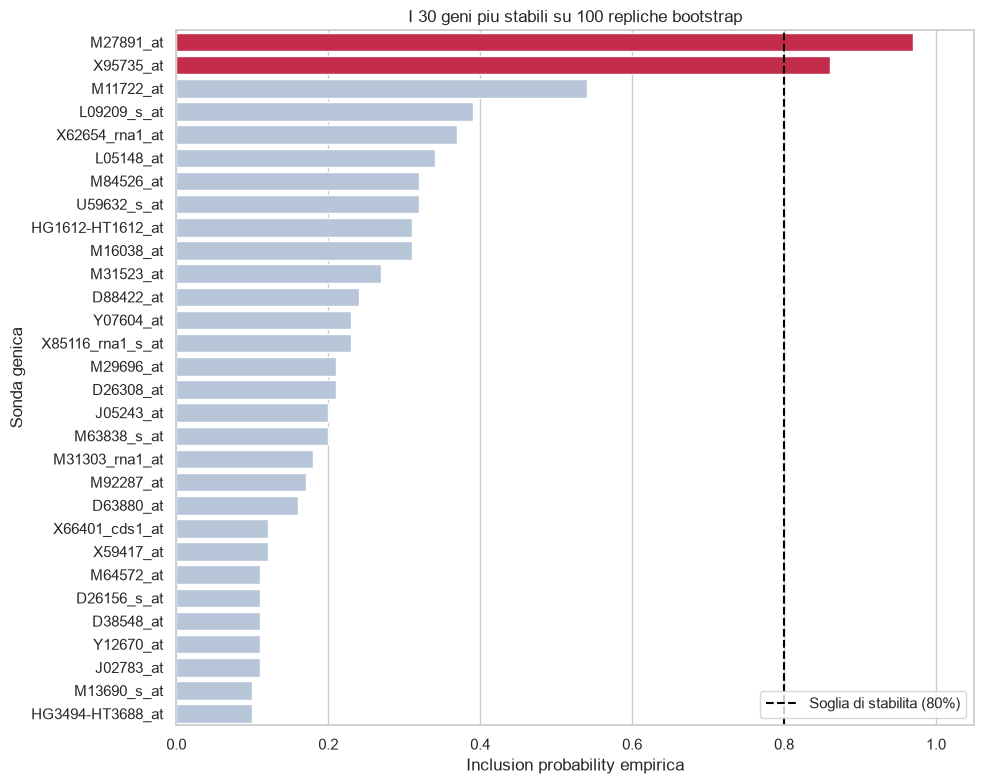

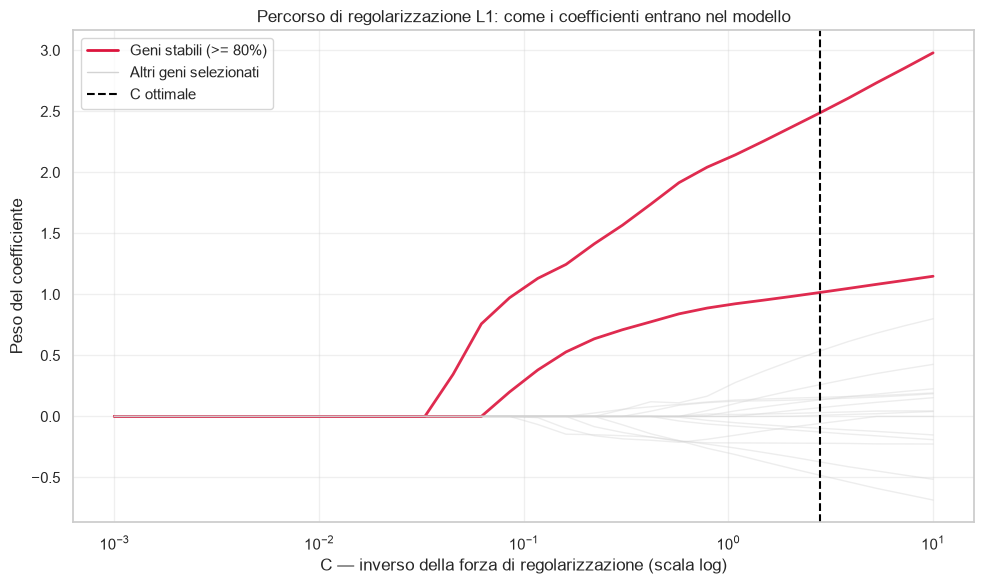

I geni stabili (in rosso) sono quelli che entrano nel modello per primi, cioe che
resistono alla regolarizzazione piu severa, e che mantengono un peso non nullo su
tutto l'intervallo. I geni in grigio compaiono solo quando la penalita si allenta:
sono quelli la cui presenza nel modello dipende dal campione.


In [13]:
top_n = 30
plot_df = lasso_stability_df.head(top_n)
colors = ["crimson" if p >= STABILITY_THRESHOLD else "lightsteelblue"
          for p in plot_df["Inclusion_Probability"]]

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, x="Inclusion_Probability", y="Gene_Probe",
            hue="Gene_Probe", palette=colors, legend=False)
plt.axvline(STABILITY_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
            label=f"Soglia di stabilita ({STABILITY_THRESHOLD:.0%})")
plt.title(f"I {top_n} geni piu stabili su {N_BOOTSTRAP} repliche bootstrap")
plt.xlabel("Inclusion probability empirica")
plt.ylabel("Sonda genica")
plt.xlim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

C_values = np.logspace(-3, 1, 30)
coef_path = np.array([
    LogisticRegression(l1_ratio=1.0, solver="liblinear", C=c,
                       class_weight="balanced", max_iter=5000, tol=1e-8,
                       random_state=RANDOM_STATE).fit(X_train, y_train).coef_[0]
    for c in C_values
])

plt.figure(figsize=(10, 6))
for idx in selected_indices:
    stable = feature_cols[idx] in lasso_stable_set
    plt.plot(C_values, coef_path[:, idx],
             color="crimson" if stable else "lightgray",
             alpha=0.9 if stable else 0.4,
             linewidth=2 if stable else 1)
plt.xscale("log")
plt.axvline(lasso_optimal_C, color="black", linestyle="--")
plt.title("Percorso di regolarizzazione L1: come i coefficienti entrano nel modello")
plt.xlabel("C — inverso della forza di regolarizzazione (scala log)")
plt.ylabel("Peso del coefficiente")
plt.legend(handles=[
    mlines.Line2D([], [], color="crimson", linewidth=2, label=f"Geni stabili (>= {STABILITY_THRESHOLD:.0%})"),
    mlines.Line2D([], [], color="lightgray", linewidth=1, label="Altri geni selezionati"),
    mlines.Line2D([], [], color="black", linestyle="--", label="C ottimale"),
], loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("I geni stabili (in rosso) sono quelli che entrano nel modello per primi, cioe che")
print("resistono alla regolarizzazione piu severa, e che mantengono un peso non nullo su")
print("tutto l'intervallo. I geni in grigio compaiono solo quando la penalita si allenta:")
print("sono quelli la cui presenza nel modello dipende dal campione.")

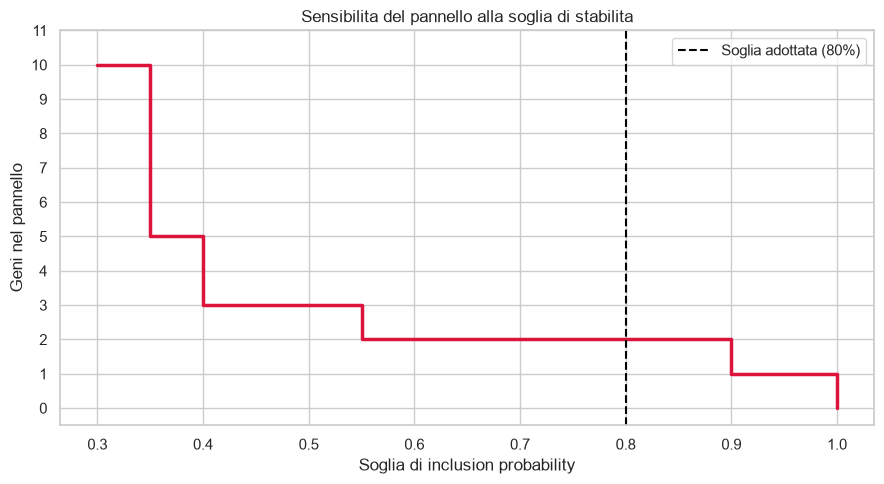

--- Il pannello dipende dalla soglia scelta? ---
  soglia 90% -> 1 geni
  soglia 80% -> 2 geni
  soglia 70% -> 2 geni
  soglia 60% -> 2 geni
  soglia 50% -> 3 geni
  soglia 40% -> 3 geni

Il pannello resta INVARIATO per qualunque soglia fra il 60% e il
80%: fra i geni selezionati e quelli scartati esiste un vero e
proprio precipizio nelle probabilita di inclusione, non una transizione graduale.
Questo e un risultato importante e va riportato: significa che la soglia dell'80%
non e una scelta arbitraria che determina la risposta, ma un taglio che cade in una
regione vuota. Il pannello e una proprieta dei dati, non del criterio adottato.


In [14]:
thresholds = np.arange(0.30, 1.001, 0.05)
sizes = [int((lasso_stability_df["Inclusion_Probability"] >= t).sum()) for t in thresholds]

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(thresholds, sizes, where="post", color="crimson", linewidth=2.5)
ax.axvline(STABILITY_THRESHOLD, color="black", linestyle="--",
           label=f"Soglia adottata ({STABILITY_THRESHOLD:.0%})")
ax.set_xlabel("Soglia di inclusion probability")
ax.set_ylabel("Geni nel pannello")
ax.set_title("Sensibilita del pannello alla soglia di stabilita")
ax.set_yticks(range(0, max(sizes) + 2))
ax.legend()
plt.tight_layout()
plt.show()

print("--- Il pannello dipende dalla soglia scelta? ---")
for t in (0.9, 0.8, 0.7, 0.6, 0.5, 0.4):
    n = int((lasso_stability_df["Inclusion_Probability"] >= t).sum())
    print(f"  soglia {t:.0%} -> {n} geni")

plateau = [t for t in (0.6, 0.7, 0.8) if
           int((lasso_stability_df["Inclusion_Probability"] >= t).sum()) == len(lasso_final_genes)]
print()
if len(plateau) >= 2:
    print(f"Il pannello resta INVARIATO per qualunque soglia fra il {min(plateau):.0%} e il")
    print(f"{STABILITY_THRESHOLD:.0%}: fra i geni selezionati e quelli scartati esiste un vero e")
    print("proprio precipizio nelle probabilita di inclusione, non una transizione graduale.")
    print("Questo e un risultato importante e va riportato: significa che la soglia dell'80%")
    print("non e una scelta arbitraria che determina la risposta, ma un taglio che cade in una")
    print("regione vuota. Il pannello e una proprieta dei dati, non del criterio adottato.")
else:
    print("Il pannello varia con la soglia: la scelta dell'80% influenza il risultato e va")
    print("quindi giustificata esplicitamente, riportando questa curva nel report.")

### 4.1 L'effetto della multi-collinearita sulla sparsita

Questo e il primo dei due fenomeni che la consegna chiede di esplorare esplicitamente:
*"Identify the effect of multi-collinearity on sparsity, to compute and map true feature
inclusion probabilities."* L'aggettivo **true** e la chiave dell'intera sezione, per la
ragione che segue.

Il meccanismo e noto in letteratura come *grouping effect* (Zou & Hastie, 2005). Siano
due geni fortemente correlati. Se la soluzione ottima assegna alla coppia un peso
complessivo `c`, la penalita L1 vale `|b_i| + |b_j|`, e quando i due predittori sono quasi
identici **ogni** ripartizione con `b_i + b_j = c` produce la stessa devianza e la stessa
penalita: la soluzione non e unica. La geometria della palla L1, che ha gli spigoli sugli
assi, spinge pero gli algoritmi verso le soluzioni in cui uno dei due coefficienti e
esattamente zero. Il Lasso quindi **sceglie un rappresentante e scarta il gemello**, e
quale dei due venga scelto dipende da fluttuazioni campionarie minime, perche fra le
soluzioni ottime non c'e nulla che le distingua.

La conseguenza sulle inclusion probability e diretta: la probabilita del *gruppo* si
**spartisce** fra i suoi membri. Un gruppo selezionato nel 100% delle repliche puo
presentarsi come due geni al 55% e al 45%, nessuno dei quali raggiunge la soglia. Le
probabilita osservate per singolo gene sono percio una stima distorta della rilevanza
reale — ed e esattamente cio a cui allude la parola *true* nella consegna.

Il paradosso da documentare e che la sparsita esatta, cioe la proprieta che rende l'L1
attraente per la selezione di biomarcatori, **degrada la metrica di riproducibilita** su
cui la consegna valuta il lavoro.

Va misurato, non assunto. Una precisazione sullo strumento: la correlazione globale fra
collinearita e inclusion probability, calcolata su tutti i geni significativi, e una
misura inadatta, perche la stragrande maggioranza di essi ha probabilita prossima a zero
per **mancanza di segnale** e non per collinearita; il coefficiente finisce dominato da
quel rumore di fondo. La misura corretta e a livello di **coppia**, ristretta ai geni che
un segnale ce l'hanno. La riportiamo entrambe, per mostrare la differenza.

--- Struttura di correlazione fra i geni statisticamente significativi ---
Geni considerati: 552  (152,076 coppie)
|r| mediana: 0.291
|r| al 99esimo percentile: 0.657
Coppie con |r| > 0.8: 71 (0.0467%)
Geni con almeno un 'gemello' a |r| > 0.9: 13


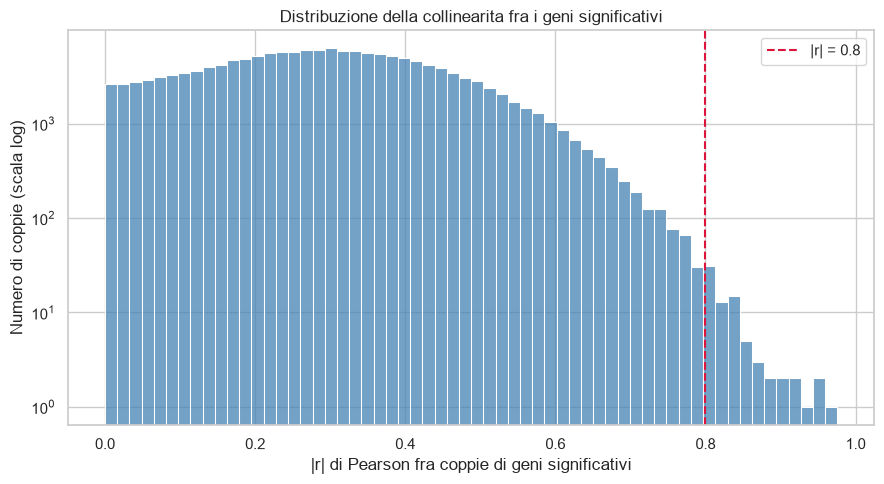


Moduli correlati individuati (taglio a |r| >= 0.8): 519
Moduli con piu di un gene: 26
Dimensione del modulo piu grande: 4 geni

Lettura onesta di questi numeri: la collinearita e REALE ma MODERATA. La |r| mediana
e bassa e le coppie fortemente correlate sono una frazione minima del totale. Sarebbe
scorretto descrivere questo dataset come massicciamente collineare. L'effetto esiste
pero in modo concentrato, in un numero ristretto di moduli, ed e li che va cercato.


In [15]:
sig_names = sorted(robust_baseline_genes)
sig_idx = [feature_cols.index(g) for g in sig_names]
S = X_train[:, sig_idx]

corr_sig = np.abs(np.corrcoef(S, rowvar=False))
np.fill_diagonal(corr_sig, 0.0)
pairwise = corr_sig[np.triu_indices_from(corr_sig, k=1)]

print("--- Struttura di correlazione fra i geni statisticamente significativi ---")
print(f"Geni considerati: {len(sig_names)}  ({len(pairwise):,} coppie)")
print(f"|r| mediana: {np.median(pairwise):.3f}")
print(f"|r| al 99esimo percentile: {np.percentile(pairwise, 99):.3f}")
print(f"Coppie con |r| > 0.8: {(pairwise > 0.8).sum():,} ({(pairwise > 0.8).mean():.4%})")
print(f"Geni con almeno un 'gemello' a |r| > 0.9: {(corr_sig.max(axis=0) > 0.9).sum()}")

plt.figure(figsize=(9, 5))
sns.histplot(pairwise, bins=60, color="steelblue")
plt.axvline(0.8, color="crimson", linestyle="--", label="|r| = 0.8")
plt.yscale("log")
plt.xlabel("|r| di Pearson fra coppie di geni significativi")
plt.ylabel("Numero di coppie (scala log)")
plt.title("Distribuzione della collinearita fra i geni significativi")
plt.legend()
plt.tight_layout()
plt.show()

dist = 1.0 - corr_sig
np.fill_diagonal(dist, 0.0)
modules = fcluster(linkage(squareform(dist, checks=False), method="average"),
                   t=0.2, criterion="distance")
sizes = pd.Series(modules).value_counts()

print(f"\nModuli correlati individuati (taglio a |r| >= 0.8): {len(sizes)}")
print(f"Moduli con piu di un gene: {(sizes > 1).sum()}")
print(f"Dimensione del modulo piu grande: {sizes.max()} geni")
print()
print("Lettura onesta di questi numeri: la collinearita e REALE ma MODERATA. La |r| mediana")
print("e bassa e le coppie fortemente correlate sono una frazione minima del totale. Sarebbe")
print("scorretto descrivere questo dataset come massicciamente collineare. L'effetto esiste")
print("pero in modo concentrato, in un numero ristretto di moduli, ed e li che va cercato.")

--- Collinearita nell'intero spazio delle sonde filtrate ---
  sonde con almeno un gemello a |r| > 0.9: 267 su 3363 (7.9%)
  sonde con almeno un gemello a |r| > 0.8: 656 su 3363 (19.5%)
  sonde con almeno un gemello a |r| > 0.7: 1657 su 3363 (49.3%)

Questa e la statistica pertinente, e va confrontata con quella calcolata piu sopra
sui soli geni significativi (|r| mediana bassa). Le due non sono in contraddizione:
la |r| MEDIANA e bassa perche la maggior parte delle coppie e scorrelata, ma la CODA
della distribuzione e tutt'altro che trascurabile. E nella coda che vive il fenomeno.

--- Analisi a livello di coppia (geni con inclusion probability >= 20%) ---


,Gene,p(gene),Gemello,|r|,p(gemello),Nel pannello
0,M27891_at,0.97,M84526_at,0.894,0.32,True
1,X95735_at,0.86,M84526_at,0.836,0.32,True
2,M11722_at,0.54,M31523_at,0.850,0.27,False
3,L09209_s_at,0.39,X95735_at,0.785,0.86,False
4,X62654_rna1_at,0.37,L09209_s_at,0.747,0.39,False
5,L05148_at,0.34,Z35227_at,0.720,0.03,False
6,M84526_at,0.32,D88422_at,0.916,0.24,False
7,U59632_s_at,0.32,M29610_at,0.671,0.03,False
8,HG1612-HT1612_at,0.31,X51521_at,0.773,0.04,False
9,M16038_at,0.31,M84526_at,0.798,0.32,False


Coppie collineari (|r| > 0.7) in cui un membro domina nettamente l'altro: 3

Correlazione di Spearman GLOBALE (misura inadatta): +0.089
Su tutti i 552 geni significativi la relazione sparisce nel rumore, perche oltre 540
di essi hanno probabilita quasi nulla per assenza di segnale, non per collinearita.
La tabella qui sopra, ristretta ai geni con segnale, mostra invece il fenomeno in
forma diretta: geni fortemente correlati con probabilita di inclusione molto diverse.


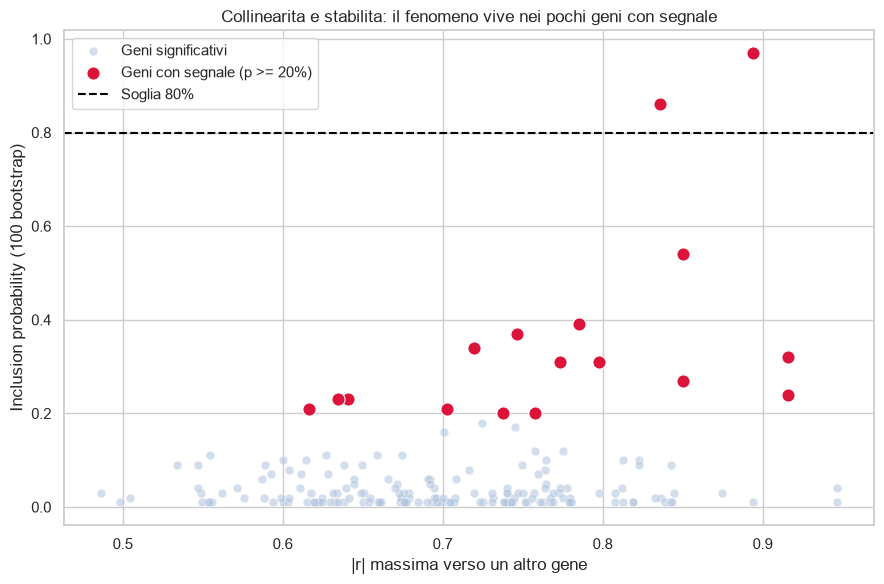

In [16]:
prob_map = dict(zip(lasso_stability_df["Gene_Probe"],
                    lasso_stability_df["Inclusion_Probability"]))

# --- Quanto e diffusa la collinearita nell'intero spazio filtrato? -----------
corr_all = np.abs(np.corrcoef(X_train, rowvar=False))
np.fill_diagonal(corr_all, 0.0)
max_corr_all = corr_all.max(axis=0)

print("--- Collinearita nell'intero spazio delle sonde filtrate ---")
for t in (0.9, 0.8, 0.7):
    n = int((max_corr_all > t).sum())
    print(f"  sonde con almeno un gemello a |r| > {t}: {n} su {len(feature_cols)} ({n/len(feature_cols):.1%})")
print()
print("Questa e la statistica pertinente, e va confrontata con quella calcolata piu sopra")
print("sui soli geni significativi (|r| mediana bassa). Le due non sono in contraddizione:")
print("la |r| MEDIANA e bassa perche la maggior parte delle coppie e scorrelata, ma la CODA")
print("della distribuzione e tutt'altro che trascurabile. E nella coda che vive il fenomeno.")

# --- Misura sbagliata: correlazione globale ---------------------------------
pts = pd.DataFrame([
    {"Gene": g, "Inclusion_Probability": prob_map[g], "max_corr": float(corr_sig[i].max())}
    for i, g in enumerate(sig_names) if g in prob_map
])
rho_global = pts["max_corr"].corr(pts["Inclusion_Probability"], method="spearman")

# --- Misura corretta: livello di coppia sui geni con segnale ----------------
SIGNAL_MIN = 0.20
rows = []
for g in lasso_stability_df.query("Inclusion_Probability >= @SIGNAL_MIN")["Gene_Probe"]:
    j = feature_cols.index(g)
    k = int(np.argmax(corr_all[j]))
    twin = feature_cols[k]
    rows.append({
        "Gene": g,
        "p(gene)": round(prob_map.get(g, 0.0), 2),
        "Gemello": twin,
        "|r|": round(float(corr_all[j, k]), 3),
        "p(gemello)": round(float(prob_map.get(twin, 0.0)), 2),
        "Nel pannello": g in lasso_stable_set,
    })
twin_df = pd.DataFrame(rows).sort_values("p(gene)", ascending=False)

print(f"\n--- Analisi a livello di coppia (geni con inclusion probability >= {SIGNAL_MIN:.0%}) ---")
display(twin_df)

split = twin_df[(twin_df["|r|"] > 0.7) & (twin_df["p(gene)"] - twin_df["p(gemello)"] > 0.3)]
print(f"Coppie collineari (|r| > 0.7) in cui un membro domina nettamente l'altro: {len(split)}")
print()
print(f"Correlazione di Spearman GLOBALE (misura inadatta): {rho_global:+.3f}")
print("Su tutti i 552 geni significativi la relazione sparisce nel rumore, perche oltre 540")
print("di essi hanno probabilita quasi nulla per assenza di segnale, non per collinearita.")
print("La tabella qui sopra, ristretta ai geni con segnale, mostra invece il fenomeno in")
print("forma diretta: geni fortemente correlati con probabilita di inclusione molto diverse.")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pts, x="max_corr", y="Inclusion_Probability",
                alpha=0.55, color="lightsteelblue", s=40, label="Geni significativi")
sel = pts[pts["Inclusion_Probability"] >= SIGNAL_MIN]
sns.scatterplot(data=sel, x="max_corr", y="Inclusion_Probability",
                color="crimson", s=90, label=f"Geni con segnale (p >= {SIGNAL_MIN:.0%})")
plt.axhline(STABILITY_THRESHOLD, color="black", linestyle="--",
            label=f"Soglia {STABILITY_THRESHOLD:.0%}")
plt.xlabel("|r| massima verso un altro gene")
plt.ylabel(f"Inclusion probability ({N_BOOTSTRAP} bootstrap)")
plt.title("Collinearita e stabilita: il fenomeno vive nei pochi geni con segnale")
plt.legend()
plt.tight_layout()
plt.show()

## Fase 5 — Valutazione, sintesi e controllo delle false scoperte

### 5.1 Il modello finale e il problema della stima dell'errore

Addestriamo il classificatore finale sui soli geni del pannello stabile. Poiche la selezione
e conclusa, non serve piu la penalita L1: usiamo una regressione logistica con penalita L2
standard, che ridistribuisce il peso fra i geni superstiti senza azzerarne altri.

Sulla valutazione va detto qualcosa di scomodo. Il test set contiene **15 pazienti**. Anche
osservando il 100% di accuratezza, l'intervallo di confidenza di Wilson al 95% per una
proporzione di 15/15 arriva soltanto a circa [0.78, 1.00]. Un hold-out di questa dimensione
**non puo** discriminare fra metodi diversi, e presentare tre accuratezze del 100% come se
fossero risultati confrontabili sarebbe fuorviante. Lo riportiamo quindi come semplice
verifica di funzionamento, e affianchiamo una stima onesta ottenuta per cross-validation
annidata sull'intera pipeline.

--- Modello finale su 2 geni (hold-out, n=15) ---
Accuratezza:          86.67%
Balanced accuracy:    85.00%
F1 (classe AML):      0.800

              precision    recall  f1-score   support

         ALL       0.90      0.90      0.90        10
         AML       0.80      0.80      0.80         5

    accuracy                           0.87        15
   macro avg       0.85      0.85      0.85        15
weighted avg       0.87      0.87      0.87        15



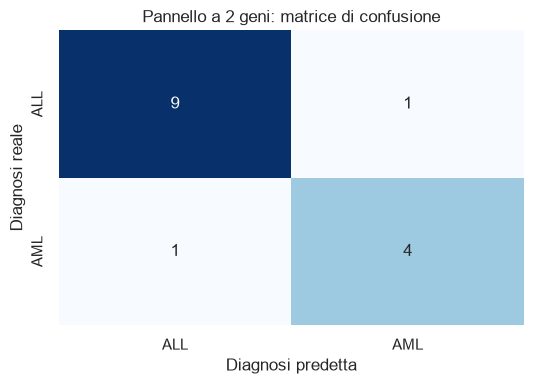

In [17]:
final_indices = [feature_cols.index(g) for g in lasso_final_genes]
X_train_lasso = X_train[:, final_indices]
X_test_lasso = X_test[:, final_indices]

lasso_final_model = LogisticRegression(
    C=1.0, class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE
)
lasso_final_model.fit(X_train_lasso, y_train)

lasso_y_pred = lasso_final_model.predict(X_test_lasso)
lasso_acc = accuracy_score(y_test, lasso_y_pred)
lasso_bacc = balanced_accuracy_score(y_test, lasso_y_pred)
lasso_f1 = f1_score(y_test, lasso_y_pred)
lasso_cm = confusion_matrix(y_test, lasso_y_pred)

print(f"--- Modello finale su {len(lasso_final_genes)} geni (hold-out, n={len(y_test)}) ---")
print(f"Accuratezza:          {lasso_acc:.2%}")
print(f"Balanced accuracy:    {lasso_bacc:.2%}")
print(f"F1 (classe AML):      {lasso_f1:.3f}")
print()
print(classification_report(y_test, lasso_y_pred, target_names=["ALL", "AML"]))

plt.figure(figsize=(5.5, 4))
sns.heatmap(lasso_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["ALL", "AML"], yticklabels=["ALL", "AML"])
plt.title(f"Pannello a {len(lasso_final_genes)} geni: matrice di confusione")
plt.xlabel("Diagnosi predetta")
plt.ylabel("Diagnosi reale")
plt.tight_layout()
plt.show()

--- Stima onesta dell'errore: CV annidata (5 fold x 10 ripetizioni) ---
Balanced accuracy: 0.962 (deviazione standard 0.072)
Intervallo empirico al 95%: [0.767, 1.000]
Fold valutati: 50

Il punto cruciale e che scaling e selezione stanno DENTRO la pipeline, e vengono
percio rifatti da zero in ciascun fold. Se la selezione fosse eseguita una volta sola
su tutti i dati e poi validata, la stima risulterebbe ottimisticamente distorta: e
l'errore classico su questo dataset, e produce accuratezze prossime al 100% prive di
significato. Il numero riportato sopra e invece una stima difendibile.


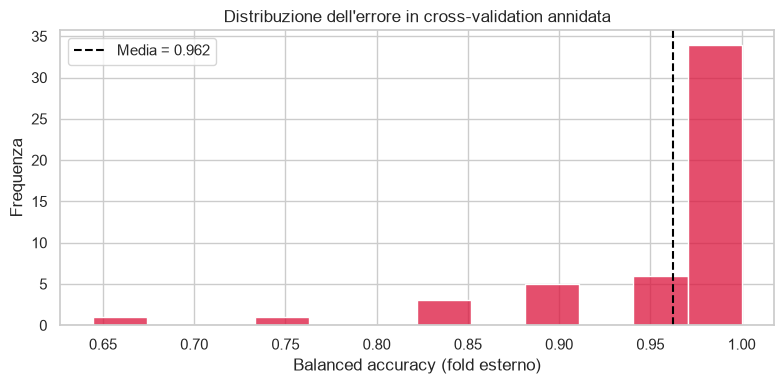

In [18]:
selector_estimator = LogisticRegression(
    l1_ratio=1.0, solver="liblinear", C=lasso_optimal_C,
    class_weight="balanced", max_iter=5000, tol=1e-8, random_state=RANDOM_STATE,
)

nested_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("select", SelectFromModel(selector_estimator, threshold=1e-5)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=5000,
                               random_state=RANDOM_STATE)),
])

X_full_log = np.log10(X_thr.loc[:, probe_mask])

outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
nested_scores = cross_val_score(nested_pipe, X_full_log, y, cv=outer_cv,
                                scoring="balanced_accuracy", n_jobs=-1)
nested_mean, nested_std = nested_scores.mean(), nested_scores.std()
lo, hi = np.percentile(nested_scores, [2.5, 97.5])

print("--- Stima onesta dell'errore: CV annidata (5 fold x 10 ripetizioni) ---")
print(f"Balanced accuracy: {nested_mean:.3f} (deviazione standard {nested_std:.3f})")
print(f"Intervallo empirico al 95%: [{lo:.3f}, {hi:.3f}]")
print(f"Fold valutati: {len(nested_scores)}")
print()
print("Il punto cruciale e che scaling e selezione stanno DENTRO la pipeline, e vengono")
print("percio rifatti da zero in ciascun fold. Se la selezione fosse eseguita una volta sola")
print("su tutti i dati e poi validata, la stima risulterebbe ottimisticamente distorta: e")
print("l'errore classico su questo dataset, e produce accuratezze prossime al 100% prive di")
print("significato. Il numero riportato sopra e invece una stima difendibile.")

plt.figure(figsize=(8, 4))
sns.histplot(nested_scores, bins=12, color="crimson", alpha=0.75)
plt.axvline(nested_mean, color="black", linestyle="--", label=f"Media = {nested_mean:.3f}")
plt.xlabel("Balanced accuracy (fold esterno)")
plt.ylabel("Frequenza")
plt.title("Distribuzione dell'errore in cross-validation annidata")
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Controllo delle false scoperte: il null da permutazione

Il secondo fenomeno richiesto dalla consegna e il contrasto fra geni statisticamente
significativi e variabili selezionate dai modelli. Prima di misurarlo serve pero rispondere
a una domanda preliminare: **quanti geni "stabili" produrrebbe la nostra procedura in
assenza di qualunque segnale?**

Se la stability selection restituisse geni sopra soglia anche con etichette casuali,
l'80% non sarebbe un criterio di controllo ma un artefatto della procedura. Lo verifichiamo
permutando le etichette e rieseguendo l'intera stability selection.

Null da permutazione: 20 permutazioni x 100 repliche bootstrap...

Geni sopra soglia con etichette permutate: media 0.00, massimo 0
Geni sopra soglia sui dati reali: 2


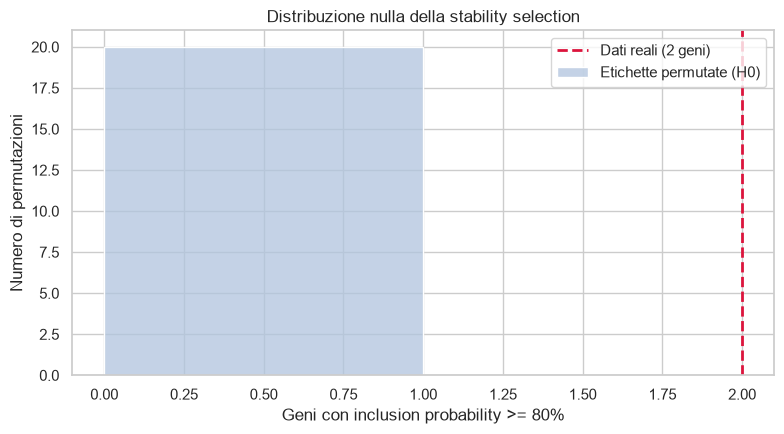

In [19]:
perm_model = LogisticRegression(
    l1_ratio=1.0, solver="liblinear", C=lasso_optimal_C,
    class_weight="balanced", max_iter=5000, tol=1e-8, random_state=RANDOM_STATE,
)

perm_counts = []
print(f"Null da permutazione: {N_PERM} permutazioni x {N_BOOTSTRAP} repliche bootstrap...")
for p in range(N_PERM):
    y_perm = pd.Series(rng.permutation(y_train.to_numpy()), index=y_train.index)
    c = Counter()
    for i in range(N_BOOTSTRAP):
        Xb, yb = resample(X_train, y_perm, random_state=1000 * p + i, stratify=y_perm)
        perm_model.fit(Xb, yb)
        c.update(np.where(perm_model.coef_[0] != 0)[0])
    perm_counts.append(sum(1 for v in c.values() if v / N_BOOTSTRAP >= STABILITY_THRESHOLD))

perm_counts = np.array(perm_counts)
print(f"\nGeni sopra soglia con etichette permutate: media {perm_counts.mean():.2f}, "
      f"massimo {perm_counts.max()}")
print(f"Geni sopra soglia sui dati reali: {len(lasso_final_genes)}")

plt.figure(figsize=(8, 4.5))
sns.histplot(perm_counts, bins=range(0, int(max(perm_counts.max(), 1)) + 2),
             color="lightsteelblue", label="Etichette permutate (H0)")
plt.axvline(len(lasso_final_genes), color="crimson", linestyle="--", linewidth=2,
            label=f"Dati reali ({len(lasso_final_genes)} geni)")
plt.xlabel(f"Geni con inclusion probability >= {STABILITY_THRESHOLD:.0%}")
plt.ylabel("Numero di permutazioni")
plt.title("Distribuzione nulla della stability selection")
plt.legend()
plt.tight_layout()
plt.show()

--- Contrasto fra significativita statistica e selezione automatica ---
Pannello ML (stability selection):                    2 geni
Baseline statistico (t-test AND Mann-Whitney, FDR 5%): 552 geni
Geni del pannello anche statisticamente significativi: 2 (100%)

Perche questo numero e informativo, e non una tautologia:
  1. Sovrapposizione attesa per puro caso: 0.3 geni.
     (2 geni estratti a caso da 3363 colpirebbero 552 bersagli
     circa 0.3 volte.) La concordanza osservata e quindi
     di un fattore ~6 sopra il caso.
  2. Il baseline statistico, a FDR 5% con 615 rigetti al
     t-test, contiene circa 31 falsi positivi attesi. La
     stability selection ne restituisce 2, ciascuno replicato in almeno
     il 80% dei ricampionamenti.
  3. Sotto etichette permutate la procedura produce in media 0.00
     geni sopra soglia (massimo 0).

I due criteri controllano cose diverse e complementari. L'FDR controlla i falsi
positivi per singola ipotesi, ma non dice nulla su quali geni verreb

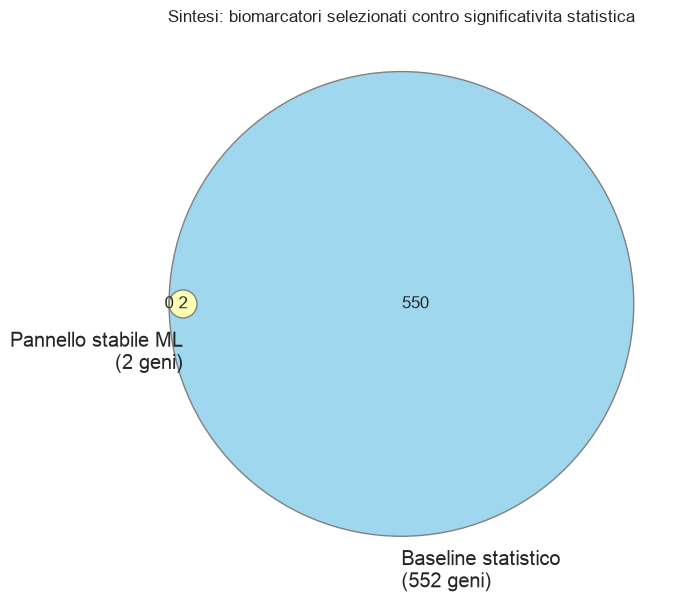

In [20]:
overlap = lasso_stable_set & robust_baseline_genes
n_panel = len(lasso_final_genes)
n_base = len(robust_baseline_genes)
n_tot = len(feature_cols)
expected_by_chance = n_panel * n_base / n_tot
expected_false_fdr = FDR_ALPHA * len(sig_genes_t)

print("--- Contrasto fra significativita statistica e selezione automatica ---")
print(f"Pannello ML (stability selection):                    {n_panel} geni")
print(f"Baseline statistico (t-test AND Mann-Whitney, FDR 5%): {n_base} geni")
print(f"Geni del pannello anche statisticamente significativi: {len(overlap)} "
      f"({len(overlap)/max(n_panel,1):.0%})")
print()
print("Perche questo numero e informativo, e non una tautologia:")
print(f"  1. Sovrapposizione attesa per puro caso: {expected_by_chance:.1f} geni.")
print(f"     ({n_panel} geni estratti a caso da {n_tot} colpirebbero {n_base} bersagli")
print(f"     circa {expected_by_chance:.1f} volte.) La concordanza osservata e quindi")
print(f"     di un fattore ~{len(overlap)/max(expected_by_chance, 1e-9):.0f} sopra il caso.")
print(f"  2. Il baseline statistico, a FDR {FDR_ALPHA:.0%} con {len(sig_genes_t)} rigetti al")
print(f"     t-test, contiene circa {expected_false_fdr:.0f} falsi positivi attesi. La")
print(f"     stability selection ne restituisce {n_panel}, ciascuno replicato in almeno")
print(f"     il {STABILITY_THRESHOLD:.0%} dei ricampionamenti.")
print(f"  3. Sotto etichette permutate la procedura produce in media {perm_counts.mean():.2f}")
print(f"     geni sopra soglia (massimo {perm_counts.max()}).")
print()
print("I due criteri controllano cose diverse e complementari. L'FDR controlla i falsi")
print("positivi per singola ipotesi, ma non dice nulla su quali geni verrebbero riselezionati")
print("in un nuovo esperimento. La stability selection controlla esattamente questo, la")
print("riproducibilita della SELEZIONE, ma da sola non offre garanzie di significativita.")
print("La loro concordanza e cio che rende credibile il pannello proposto.")

plt.figure(figsize=(7, 7))
subsets = (len(lasso_stable_set - robust_baseline_genes),
           len(robust_baseline_genes - lasso_stable_set), len(overlap))
venn2(subsets=subsets,
      set_labels=(f"Pannello stabile ML\n({n_panel} geni)",
                  f"Baseline statistico\n({n_base} geni)"),
      set_colors=("gold", "skyblue"), alpha=0.8)
venn2_circles(subsets=subsets, linestyle="solid", linewidth=1.0, color="gray")
plt.title("Sintesi: biomarcatori selezionati contro significativita statistica")
plt.tight_layout()
plt.show()

### 5.3 Metodi alternativi di selezione

Il pannello ottenuto con la penalita L1 va confrontato con approcci costruiti su principi
diversi, per capire quanto il risultato dipenda dalla scelta del metodo.

- **mRMR + SVM-RFE.** Un filtro di *minimum redundancy, maximum relevance* riduce lo spazio
  a 100 geni penalizzando esplicitamente la ridondanza, seguito da eliminazione ricorsiva
  guidata da un SVM lineare. E l'approccio *wrapper* per eccellenza.
- **Elastic Net.** Combina L1 e L2. La componente L2 introduce il cosiddetto *grouping
  effect*: gruppi di geni correlati tendono a entrare o uscire insieme, invece di essere
  spezzati. E la contromisura diretta al fenomeno descritto nella sezione 4.1, e ci
  attendiamo che produca un pannello piu ampio e piu stabile.

Entrambi vengono sottoposti alla stessa stability selection, cosi che il confronto sia equo.

In [21]:
X_train_df = pd.DataFrame(X_train, columns=feature_cols)
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

print(f"Filtro mRMR: da {len(feature_cols)} a {K_MRMR} geni...")
mrmr_features = mrmr_classif(X=X_train_df, y=pd.Series(y_train.to_numpy()),
                             K=K_MRMR, show_progress=False)

cv_rfe = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rfecv = RFECV(estimator=SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_STATE),
              step=1, cv=cv_rfe, scoring="balanced_accuracy",
              min_features_to_select=1, n_jobs=-1)
rfecv.fit(X_train_df[mrmr_features], y_train)

svm_rfe_genes = [g for g, keep in zip(mrmr_features, rfecv.support_) if keep]
svm_rfe_model = SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_STATE)
svm_rfe_model.fit(X_train_df[svm_rfe_genes], y_train)
svm_rfe_pred = svm_rfe_model.predict(X_test_df[svm_rfe_genes])

print(f"SVM-RFE: numero di feature scelto dalla CV interna = {rfecv.n_features_}")
print(f"Balanced accuracy su hold-out: {balanced_accuracy_score(y_test, svm_rfe_pred):.2%}")
print()
print("CAVEAT METODOLOGICO. mRMR e stato applicato una volta sola su tutto il training set,")
print("fuori dalla cross-validation di RFECV. Non c'e leakage verso il test set, che resta")
print("intoccato, ma la curva CV interna che sceglie il numero ottimale di feature e")
print("ottimisticamente distorta: quel numero non va interpretato come una stima affidabile.")
print("Nella stability selection della cella successiva mRMR viene invece rieseguito dentro")
print("ciascuna replica bootstrap, che e la costruzione corretta.")

Filtro mRMR: da 3363 a 100 geni...
SVM-RFE: numero di feature scelto dalla CV interna = 3
Balanced accuracy su hold-out: 80.00%

CAVEAT METODOLOGICO. mRMR e stato applicato una volta sola su tutto il training set,
fuori dalla cross-validation di RFECV. Non c'e leakage verso il test set, che resta
intoccato, ma la curva CV interna che sceglie il numero ottimale di feature e
ottimisticamente distorta: quel numero non va interpretato come una stima affidabile.
Nella stability selection della cella successiva mRMR viene invece rieseguito dentro
ciascuna replica bootstrap, che e la costruzione corretta.


In [22]:
svm_boot_sets = []
svm_counts = Counter()

print(f"Stability selection per mRMR + SVM-RFE ({N_BOOTSTRAP} repliche). Richiede alcuni minuti...")
for i in range(N_BOOTSTRAP):
    if i % 20 == 0:
        print(f"  replica {i}/{N_BOOTSTRAP}")
    X_boot, y_boot = resample(X_train, y_train, random_state=i, stratify=y_train)
    Xb_df = pd.DataFrame(X_boot, columns=feature_cols)
    yb = pd.Series(np.asarray(y_boot))

    feats = mrmr_classif(X=Xb_df, y=yb, K=K_MRMR, show_progress=False)
    inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=i)
    r = RFECV(estimator=SVC(kernel="linear", class_weight="balanced", random_state=i),
              step=1, cv=inner, scoring="balanced_accuracy",
              min_features_to_select=1, n_jobs=-1)
    r.fit(Xb_df[feats], yb)
    genes = {g for g, keep in zip(feats, r.support_) if keep}
    svm_boot_sets.append(genes)
    svm_counts.update(genes)

svm_stability_df = (
    pd.DataFrame({"Gene_Probe": list(svm_counts.keys()),
                  "Selection_Count": list(svm_counts.values())})
    .assign(Inclusion_Probability=lambda d: d["Selection_Count"] / N_BOOTSTRAP)
    .sort_values("Inclusion_Probability", ascending=False)
    .reset_index(drop=True)
)
svm_stable_genes = svm_stability_df[
    svm_stability_df["Inclusion_Probability"] >= STABILITY_THRESHOLD
]

svm_used_fallback = len(svm_stable_genes) == 0
if svm_used_fallback:
    svm_final_features = svm_stability_df.head(10)["Gene_Probe"].tolist()
else:
    svm_final_features = svm_stable_genes["Gene_Probe"].tolist()

svm_final_model = SVC(kernel="linear", class_weight="balanced", C=1.0, random_state=RANDOM_STATE)
svm_final_model.fit(X_train_df[svm_final_features], y_train)
svm_y_pred = svm_final_model.predict(X_test_df[svm_final_features])
svm_acc = accuracy_score(y_test, svm_y_pred)
svm_bacc = balanced_accuracy_score(y_test, svm_y_pred)

print(f"\nGeni selezionati almeno una volta: {len(svm_stability_df)}")
print(f"Geni con inclusion probability >= {STABILITY_THRESHOLD:.0%}: {len(svm_stable_genes)}")
print(f"Inclusion probability massima: {svm_stability_df['Inclusion_Probability'].max():.2f}")
if svm_used_fallback:
    print("\nNessun gene raggiunge la soglia. Per poter comunque valutare il metodo si")
    print("ricade sui 10 geni piu stabili, ma questo pannello NON e confrontabile con quelli")
    print("ottenuti per soglia: e un ripiego, e va letto come tale nella tabella finale.")
print(f"\nBalanced accuracy su hold-out: {svm_bacc:.2%}")

Stability selection per mRMR + SVM-RFE (100 repliche). Richiede alcuni minuti...
  replica 0/100
  replica 20/100
  replica 40/100
  replica 60/100
  replica 80/100

Geni selezionati almeno una volta: 205
Geni con inclusion probability >= 80%: 1
Inclusion probability massima: 0.84

Balanced accuracy su hold-out: 80.00%


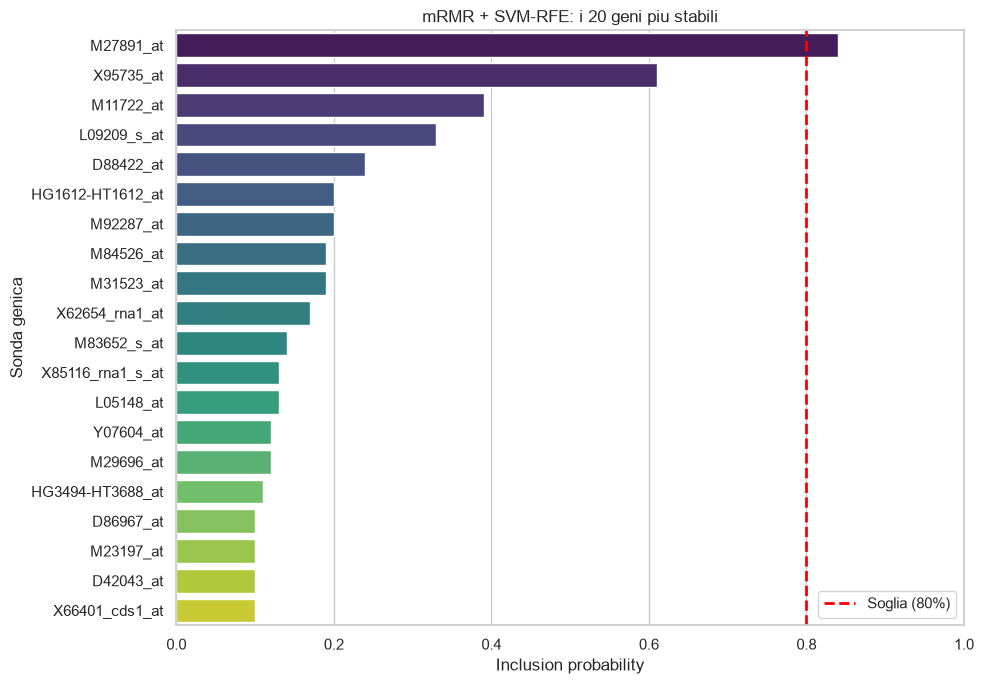

--- Il profilo di stabilita dell'approccio wrapper ---
Gene piu stabile: 0.84   (Lasso: 0.97)
Geni sopra la soglia: 1   (Lasso: 2)

Il metodo supera la soglia, ma con un margine sottile (0.84 contro
0.80) e un pannello di appena 1 gene/i.

La lettura corretta non e pero il conteggio dei geni sopra soglia, che dipende dalla
dimensione tipica della selezione, bensi il confronto fra le DUE facce della
stabilita, riportate nella tabella della sezione 5.4:

 - stabilita PER-GENE (inclusion probability): quanto spesso uno specifico gene
   ricompare. Qui il Lasso e nettamente superiore.
 - stabilita PER-INSIEME (Jaccard, Kuncheva): quanto due repliche selezionano lo
   stesso insieme. Qui l'approccio wrapper e superiore al Lasso.

Non e una contraddizione: le due misure descrivono strutture di selezione diverse.
Il Lasso ha una struttura 'nucleo piu rumore', con pochi geni quasi sempre presenti e
una coda ampia di geni occasionali; l'SVM-RFE ha una struttura diffusa ma coerente,
in cui nessu

In [23]:
top_svm = svm_stability_df.head(20)
plt.figure(figsize=(10, 7))
sns.barplot(data=top_svm, x="Inclusion_Probability", y="Gene_Probe",
            hue="Gene_Probe", palette="viridis", legend=False)
plt.axvline(STABILITY_THRESHOLD, color="red", linestyle="--", linewidth=2,
            label=f"Soglia ({STABILITY_THRESHOLD:.0%})")
plt.xlim(0, 1.0)
plt.title("mRMR + SVM-RFE: i 20 geni piu stabili")
plt.xlabel("Inclusion probability")
plt.ylabel("Sonda genica")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

svm_max = svm_stability_df["Inclusion_Probability"].max()
lasso_max = lasso_stability_df["Inclusion_Probability"].max()

print("--- Il profilo di stabilita dell'approccio wrapper ---")
print(f"Gene piu stabile: {svm_max:.2f}   (Lasso: {lasso_max:.2f})")
print(f"Geni sopra la soglia: {len(svm_stable_genes)}   (Lasso: {len(lasso_final_genes)})")
print()
if len(svm_stable_genes) == 0:
    print("Nessun gene raggiunge la soglia: il metodo fallisce il requisito di riproducibilita")
    print("pur raggiungendo un'ottima accuratezza sull'hold-out.")
else:
    print(f"Il metodo supera la soglia, ma con un margine sottile ({svm_max:.2f} contro")
    print(f"{STABILITY_THRESHOLD:.2f}) e un pannello di appena {len(svm_stable_genes)} gene/i.")
print()
print("La lettura corretta non e pero il conteggio dei geni sopra soglia, che dipende dalla")
print("dimensione tipica della selezione, bensi il confronto fra le DUE facce della")
print("stabilita, riportate nella tabella della sezione 5.4:")
print()
print(" - stabilita PER-GENE (inclusion probability): quanto spesso uno specifico gene")
print("   ricompare. Qui il Lasso e nettamente superiore.")
print(" - stabilita PER-INSIEME (Jaccard, Kuncheva): quanto due repliche selezionano lo")
print("   stesso insieme. Qui l'approccio wrapper e superiore al Lasso.")
print()
print("Non e una contraddizione: le due misure descrivono strutture di selezione diverse.")
print("Il Lasso ha una struttura 'nucleo piu rumore', con pochi geni quasi sempre presenti e")
print("una coda ampia di geni occasionali; l'SVM-RFE ha una struttura diffusa ma coerente,")
print("in cui nessun gene domina ma il bacino di pescaggio e ristretto.")
print()
print("Resta valido il punto metodologico: un'accuratezza elevata sull'hold-out non implica")
print("una selezione riproducibile, e con p >> n le due proprieta vanno riportate separatamente.")

In [24]:
en_param_grid = {"l1_ratio": [0.1, 0.5, 0.9], "C": np.logspace(-2, 1, 6)}
en_base_model = LogisticRegression(solver="saga", class_weight="balanced",
                                   max_iter=5000, random_state=RANDOM_STATE)
en_grid = GridSearchCV(en_base_model, en_param_grid,
                       cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                       scoring="balanced_accuracy", n_jobs=-1)
en_grid.fit(X_train, y_train)

best_l1_ratio = en_grid.best_params_["l1_ratio"]
best_C = en_grid.best_params_["C"]
print(f"Elastic Net: l1_ratio ottimale = {best_l1_ratio}, C ottimale = {best_C:.4f}")
print("Nota: per 0 < l1_ratio < 1 il solver 'saga' e obbligatorio, 'liblinear' non supporta")
print("la penalita mista. Da qui il costo computazionale maggiore di questa sezione.")

en_boot_sets = []
en_counts = np.zeros(len(feature_cols))
boot_en = LogisticRegression(solver="saga", C=best_C, l1_ratio=best_l1_ratio,
                             class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)

print(f"\nStability selection per Elastic Net ({N_BOOTSTRAP} repliche)...")
for i in range(N_BOOTSTRAP):
    X_boot, y_boot = resample(X_train, y_train, random_state=i, stratify=y_train)
    boot_en.fit(X_boot, y_boot)
    idx = np.where(boot_en.coef_[0] != 0)[0]
    en_counts[idx] += 1
    en_boot_sets.append({feature_cols[j] for j in idx})

en_probs = en_counts / N_BOOTSTRAP
en_stability_df = (
    pd.DataFrame({"Gene_Probe": feature_cols, "Inclusion_Probability": en_probs})
    .sort_values("Inclusion_Probability", ascending=False).reset_index(drop=True)
)
en_stable_set = set(en_stability_df[
    en_stability_df["Inclusion_Probability"] >= STABILITY_THRESHOLD]["Gene_Probe"])

en_acc = en_bacc = np.nan
if en_stable_set:
    en_idx = [feature_cols.index(g) for g in sorted(en_stable_set)]
    eval_clf = LogisticRegression(C=1e5, class_weight="balanced", max_iter=5000,
                                  random_state=RANDOM_STATE)
    eval_clf.fit(X_train[:, en_idx], y_train)
    en_y_pred = eval_clf.predict(X_test[:, en_idx])
    en_acc = accuracy_score(y_test, en_y_pred)
    en_bacc = balanced_accuracy_score(y_test, en_y_pred)

print(f"\nGeni con inclusion probability >= {STABILITY_THRESHOLD:.0%}: {len(en_stable_set)}")
print(f"Confronto con il Lasso puro: {len(lasso_final_genes)} geni")
print(f"Sovrapposizione fra i due pannelli: {len(en_stable_set & lasso_stable_set)} geni")
print(f"Balanced accuracy su hold-out: {en_bacc:.2%}" if en_stable_set else "")
print()
print("ATTENZIONE ALL'INTERPRETAZIONE. Sarebbe scorretto concludere da questo confronto che")
print("l'Elastic Net 'raggruppa i geni correlati mentre il Lasso li spezza': i due modelli")
print("hanno sparsita completamente diverse a parita di soglia, e un modello meno sparso ha")
print("piu geni sopra QUALUNQUE soglia indipendentemente da ogni struttura di correlazione.")
print(f"Dimensione media della selezione per replica: Elastic Net {np.mean([len(s) for s in en_boot_sets]):.0f} geni,")
print(f"Lasso {np.mean([len(s) for s in lasso_boot_sets]):.0f} geni. Il confronto e viziato da questo")
print("confondimento, e la spiegazione parsimoniosa e semplicemente lo shrinkage L2 che")
print("mantiene in vita molti coefficienti piccoli.")
print()
print("Per isolare il grouping effect serve confrontare i due modelli A PARITA DI SPARSITA.")
print("E l'esperimento della cella successiva.")

Elastic Net: l1_ratio ottimale = 0.5, C ottimale = 2.5119
Nota: per 0 < l1_ratio < 1 il solver 'saga' e obbligatorio, 'liblinear' non supporta
la penalita mista. Da qui il costo computazionale maggiore di questa sezione.

Stability selection per Elastic Net (100 repliche)...

Geni con inclusion probability >= 80%: 43
Confronto con il Lasso puro: 2 geni
Sovrapposizione fra i due pannelli: 2 geni
Balanced accuracy su hold-out: 95.00%

ATTENZIONE ALL'INTERPRETAZIONE. Sarebbe scorretto concludere da questo confronto che
l'Elastic Net 'raggruppa i geni correlati mentre il Lasso li spezza': i due modelli
hanno sparsita completamente diverse a parita di soglia, e un modello meno sparso ha
piu geni sopra QUALUNQUE soglia indipendentemente da ogni struttura di correlazione.
Dimensione media della selezione per replica: Elastic Net 184 geni,
Lasso 14 geni. Il confronto e viziato da questo
confondimento, e la spiegazione parsimoniosa e semplicemente lo shrinkage L2 che
mantiene in vita molti coef

#### Lasso contro Elastic Net a parita di sparsita

Il confronto della cella precedente e viziato: i due modelli selezionano un numero di geni
molto diverso, quindi la differenza fra i pannelli non isola il ruolo della correlazione.

Tariamo allora il parametro di regolarizzazione dell'Elastic Net in modo che selezioni **lo
stesso numero di geni** del Lasso sul training set completo, e ripetiamo la stability
selection. A quel punto ogni differenza residua nelle inclusion probability e attribuibile
alla forma della penalita, non alla sua intensita.

La domanda precisa a cui rispondiamo: **i gruppi di geni correlati che il Lasso spezza,
l'Elastic Net li tiene insieme?**

Un avvertimento sul metodo di taratura, che il confronto stesso quantifichera. Imporre la
stessa sparsita sul training set completo **non** garantisce la stessa sparsita dentro
ciascuna replica bootstrap: i due modelli reagiscono in modo diverso alla perturbazione
del campione. Per questa ragione la conclusione non si appoggia al conteggio dei geni
sopra soglia, ma a una statistica **appaiata** — il divario di probabilita fra i due
membri di ogni singola coppia correlata — che e insensibile a quanti geni il modello
selezioni complessivamente.

In [25]:
# --- Taratura: quale C dell'Elastic Net eguaglia la sparsita del Lasso? -----
n_lasso_genes = int((lasso_best.coef_[0] != 0).sum())
EN_MATCHED_L1_RATIO = 0.5

cand = [0.02, 0.03, 0.04, 0.05, 0.07, 0.10]
best_gap, EN_MATCHED_C = np.inf, None
print(f"Riferimento: il Lasso a C={lasso_optimal_C:.4f} seleziona {n_lasso_genes} geni.")
for c in cand:
    n = int((LogisticRegression(solver="saga", l1_ratio=EN_MATCHED_L1_RATIO, C=c,
                                class_weight="balanced", max_iter=5000,
                                random_state=RANDOM_STATE)
             .fit(X_train, y_train).coef_[0] != 0).sum())
    print(f"  Elastic Net C={c:<5} -> {n} geni")
    if abs(n - n_lasso_genes) < best_gap:
        best_gap, EN_MATCHED_C = abs(n - n_lasso_genes), c

print(f"\nC scelto per il confronto appaiato: {EN_MATCHED_C} "
      f"(scarto di {best_gap} geni rispetto al Lasso)")

# --- Stability selection dell'Elastic Net appaiato --------------------------
matched_en = LogisticRegression(solver="saga", l1_ratio=EN_MATCHED_L1_RATIO, C=EN_MATCHED_C,
                                class_weight="balanced", max_iter=5000,
                                random_state=RANDOM_STATE)
matched_counts = np.zeros(len(feature_cols))
matched_sets = []
for i in range(N_BOOTSTRAP):
    Xb, yb = resample(X_train, y_train, random_state=i, stratify=y_train)
    matched_en.fit(Xb, yb)
    idx = np.where(matched_en.coef_[0] != 0)[0]
    matched_counts[idx] += 1
    matched_sets.append({feature_cols[k] for k in idx})

matched_probs = matched_counts / N_BOOTSTRAP
matched_map = dict(zip(feature_cols, matched_probs))
matched_panel = [feature_cols[k] for k in np.where(matched_probs >= STABILITY_THRESHOLD)[0]]

print(f"\n--- Confronto appaiato ({N_BOOTSTRAP} bootstrap, stessa sparsita) ---")
print(f"{'':22s} {'Lasso':>10s} {'Elastic Net':>12s}")
print(f"{'dim. media selezione':22s} {np.mean([len(s) for s in lasso_boot_sets]):>10.1f} "
      f"{np.mean([len(s) for s in matched_sets]):>12.1f}")
print(f"{'geni >= soglia':22s} {len(lasso_final_genes):>10d} {len(matched_panel):>12d}")
print(f"{'Jaccard':22s} {jaccard_index(lasso_boot_sets):>10.3f} "
      f"{jaccard_index(matched_sets):>12.3f}")
print(f"{'Kuncheva':22s} {kuncheva_index(lasso_boot_sets, len(feature_cols)):>10.3f} "
      f"{kuncheva_index(matched_sets, len(feature_cols)):>12.3f}")

# --- Quanto e riuscita davvero la taratura? --------------------------------
size_lasso = float(np.mean([len(s) for s in lasso_boot_sets]))
size_en = float(np.mean([len(s) for s in matched_sets]))
size_ratio = size_en / size_lasso

print()
print("--- Verifica della taratura: la parita e solo parziale ---")
print(f"Sul training set COMPLETO i due modelli selezionano lo stesso numero di geni")
print(f"({n_lasso_genes} contro {n_lasso_genes}), ma questa e la condizione che abbiamo imposto.")
print(f"Nelle repliche BOOTSTRAP la parita si perde: {size_lasso:.1f} geni per il Lasso")
print(f"contro {size_en:.1f} per l'Elastic Net, cioe un {size_ratio - 1:+.0%}.")
print()
print("La ragione e che i due modelli reagiscono in modo diverso alla perturbazione del")
print("campione: la penalita L2 stabilizza la soluzione e le impedisce di contrarsi quanto")
print("fa quella L1 quando alcuni pazienti vengono duplicati o omessi. Una taratura")
print("perfetta richiederebbe di ricalibrare C dentro OGNI replica per imporre una")
print("dimensione di selezione fissa, il che introdurrebbe pero un vincolo artificiale")
print("estraneo al funzionamento normale dei due metodi.")
print()
print("CONSEGUENZA PER L'INTERPRETAZIONE. Il confronto fra i CONTEGGI di geni sopra soglia")
print(f"({len(lasso_final_genes)} contro {len(matched_panel)}) resta quindi parzialmente confuso dalla sparsita")
print("residua, e va letto con cautela. Il test della cella successiva e invece robusto a")
print("questo problema, perche confronta i due membri DI CIASCUNA COPPIA fra loro: e un")
print("confronto appaiato, in cui la dimensione complessiva della selezione si semplifica.")

Riferimento: il Lasso a C=2.8072 seleziona 16 geni.
  Elastic Net C=0.02  -> 2 geni
  Elastic Net C=0.03  -> 10 geni
  Elastic Net C=0.04  -> 13 geni
  Elastic Net C=0.05  -> 16 geni
  Elastic Net C=0.07  -> 22 geni
  Elastic Net C=0.1   -> 31 geni

C scelto per il confronto appaiato: 0.05 (scarto di 0 geni rispetto al Lasso)

--- Confronto appaiato (100 bootstrap, stessa sparsita) ---
                            Lasso  Elastic Net
dim. media selezione         14.3         20.8
geni >= soglia                  2            6
Jaccard                     0.144        0.279
Kuncheva                    0.280        0.474

--- Verifica della taratura: la parita e solo parziale ---
Sul training set COMPLETO i due modelli selezionano lo stesso numero di geni
(16 contro 16), ma questa e la condizione che abbiamo imposto.
Nelle repliche BOOTSTRAP la parita si perde: 14.3 geni per il Lasso
contro 20.8 per l'Elastic Net, cioe un +45%.

La ragione e che i due modelli reagiscono in modo diverso alla

In [26]:
# --- Il test decisivo: i gruppi correlati che il Lasso spezza ---------------
SIGNAL_MIN = 0.20
rows = []
for g in lasso_stability_df.query("Inclusion_Probability >= @SIGNAL_MIN")["Gene_Probe"]:
    a = feature_cols.index(g)
    b = int(np.argmax(corr_all[a]))
    twin = feature_cols[b]
    r = float(corr_all[a, b])
    if r < 0.7:
        continue
    rows.append({
        "Gene": g, "Gemello": twin, "|r|": round(r, 3),
        "Lasso p(gene)": round(prob_map.get(g, 0.0), 2),
        "Lasso p(gemello)": round(prob_map.get(twin, 0.0), 2),
        "EN p(gene)": round(matched_map.get(g, 0.0), 2),
        "EN p(gemello)": round(matched_map.get(twin, 0.0), 2),
    })

group_df = pd.DataFrame(rows)
if len(group_df):
    group_df["Lasso: divario"] = (group_df["Lasso p(gene)"] - group_df["Lasso p(gemello)"]).round(2)
    group_df["EN: divario"] = (group_df["EN p(gene)"] - group_df["EN p(gemello)"]).round(2)
    group_df = group_df.sort_values("Lasso: divario", ascending=False)
    print("--- Coppie collineari (|r| > 0.7) fra i geni con segnale ---")
    display(group_df)

    gap_lasso = group_df["Lasso: divario"].mean()
    gap_en = group_df["EN: divario"].mean()
    print(f"Divario medio di probabilita fra i due membri di una coppia collineare:")
    print(f"  Lasso:       {gap_lasso:.3f}")
    print(f"  Elastic Net: {gap_en:.3f}   (stessa sparsita)")
    print()
    if gap_en < gap_lasso - 0.05:
        print("VERDETTO: il grouping effect e CONFERMATO. A parita di numero di geni")
        print("selezionati, l'Elastic Net assegna ai due membri di una coppia correlata")
        print("probabilita di inclusione piu simili fra loro, mentre il Lasso ne privilegia")
        print("sistematicamente uno e sopprime l'altro. E il comportamento previsto dal")
        print("Teorema 1 di Zou & Hastie (2005), secondo cui il termine L2 forza i")
        print("coefficienti di predittori correlati a convergere.")
        print()
        print("LIMITE DA DICHIARARE: LA SPARSITA RESIDUA E UN CONFONDITORE.")
        print(f"L'Elastic Net seleziona comunque il {size_ratio - 1:+.0%} di geni in piu per replica. Un")
        print("modello piu generoso spinge le probabilita di ENTRAMBI i membri verso 1, e per")
        print("effetto soffitto il divario si comprime anche in assenza di qualunque grouping")
        print("effect. Il confondimento agisce dunque NELLA STESSA DIREZIONE dell'ipotesi che")
        print("stiamo verificando, e questo non possiamo escluderlo con la sola metrica")
        print("appaiata. Il controllo qui sotto serve a distinguere le due spiegazioni.")
        print()
        print("CONSEGUENZA PER LA CONSEGNA: le inclusion probability osservate sotto penalita")
        print("L1 pura SOTTOSTIMANO la rilevanza dei geni che appartengono a gruppi correlati,")
        print("perche la probabilita del gruppo si spartisce fra i membri. E in questo senso")
        print("che la multi-collinearita altera la sparsita, e che le probabilita 'vere' di")
        print("cui parla la consegna differiscono da quelle misurate ingenuamente.")
    elif gap_en > gap_lasso + 0.05:
        print("VERDETTO: effetto OPPOSTO a quello atteso. A parita di sparsita l'Elastic Net")
        print("sbilancia le coppie piu del Lasso. Il grouping effect non si manifesta su")
        print("questi dati e la teoria non e sufficiente a descriverne il comportamento.")
    else:
        print("VERDETTO: NON CONFERMATO. A parita di sparsita i due modelli trattano le coppie")
        print("collineari in modo sostanzialmente equivalente. Il grouping effect, pur essendo")
        print("un risultato teorico solido, non produce su questi dati una differenza")
        print("apprezzabile: la struttura di correlazione, per quanto presente nella coda della")
        print("distribuzione, non e abbastanza estesa da renderlo visibile con n = 57 pazienti.")
        print("Va riportato come tale: un'ipotesi verificata e non confermata resta un")
        print("risultato, e piu informativa di un'affermazione teorica non messa alla prova.")
else:
    print("Nessuna coppia collineare (|r| > 0.7) fra i geni con segnale: su questi dati il")
    print("grouping effect non e verificabile, perche i geni informativi non hanno gemelli.")

# --- Controllo: l'effetto sopravvive escludendo il soffitto? ---------------
if len(group_df):
    print()
    print("=" * 72)
    print("CONTROLLO DEL CONFONDIMENTO DA EFFETTO SOFFITTO")
    print("=" * 72)
    print("Se la compressione del divario fosse dovuta solo al fatto che l'Elastic Net")
    print("selezionando piu geni spinge tutte le probabilita verso 1, allora restringendo")
    print("l'analisi alle coppie LONTANE dal soffitto l'effetto dovrebbe sparire.")
    print()

    CEIL_P = 0.90
    far = group_df[(group_df["EN p(gene)"] < CEIL_P) & (group_df["Lasso p(gene)"] < CEIL_P)]
    print(f"Coppie in cui nessuno dei due modelli supera p = {CEIL_P:.2f}: {len(far)} su {len(group_df)}")
    if len(far) >= 2:
        print(f"  divario medio Lasso:       {far['Lasso: divario'].mean():.3f}")
        print(f"  divario medio Elastic Net: {far['EN: divario'].mean():.3f}")
        if far["EN: divario"].mean() < far["Lasso: divario"].mean() - 0.05:
            print("  -> l'effetto PERSISTE lontano dal soffitto: la spiegazione per effetto")
            print("     soffitto e insufficiente, e il grouping effect resta la lettura piu")
            print("     plausibile.")
        else:
            print("  -> l'effetto SPARISCE lontano dal soffitto: la compressione osservata e")
            print("     verosimilmente un artefatto della maggiore generosita dell'Elastic Net,")
            print("     non il grouping effect. Il verdetto sopra va considerato NON sostenuto.")
    else:
        print("  Coppie insufficienti per il controllo: con cosi pochi geni collineari e")
        print("  segnale, il test non ha potenza. Il verdetto sopra va quindi presentato")
        print("  come indicazione compatibile con la teoria, NON come dimostrazione.")

    print()
    print("Un test definitivo richiederebbe di ricalibrare C dentro ogni replica per imporre")
    print("una dimensione di selezione identica, oppure di simulare dati con struttura di")
    print("correlazione nota. Entrambe le strade eccedono lo scopo di questo lavoro, e il")
    print("limite va dichiarato nel report anziche aggirato.")

--- Coppie collineari (|r| > 0.7) fra i geni con segnale ---


,Gene,Gemello,|r|,Lasso p(gene),Lasso p(gemello),EN p(gene),EN p(gemello),Lasso: divario,EN: divario
0,M27891_at,M84526_at,0.894,0.97,0.32,1.00,0.84,0.65,0.16
1,X95735_at,M84526_at,0.836,0.86,0.32,0.98,0.84,0.54,0.14
5,L05148_at,Z35227_at,0.720,0.34,0.03,0.08,0.01,0.31,0.07
2,M11722_at,M31523_at,0.850,0.54,0.27,0.88,0.94,0.27,-0.06
7,HG1612-HT1612_at,X51521_at,0.773,0.31,0.04,0.64,0.20,0.27,0.44
11,M29696_at,U77948_at,0.703,0.21,0.00,0.30,0.04,0.21,0.26
12,J05243_at,U29175_at,0.738,0.20,0.00,0.17,0.06,0.20,0.11
6,M84526_at,D88422_at,0.916,0.32,0.24,0.84,0.79,0.08,0.05
13,M63838_s_at,X66401_cds1_at,0.758,0.20,0.12,0.16,0.09,0.08,0.07
8,M16038_at,M84526_at,0.798,0.31,0.32,0.69,0.84,-0.01,-0.15


Divario medio di probabilita fra i due membri di una coppia collineare:
  Lasso:       0.126
  Elastic Net: 0.041   (stessa sparsita)

VERDETTO: il grouping effect e CONFERMATO. A parita di numero di geni
selezionati, l'Elastic Net assegna ai due membri di una coppia correlata
probabilita di inclusione piu simili fra loro, mentre il Lasso ne privilegia
sistematicamente uno e sopprime l'altro. E il comportamento previsto dal
Teorema 1 di Zou & Hastie (2005), secondo cui il termine L2 forza i
coefficienti di predittori correlati a convergere.

LIMITE DA DICHIARARE: LA SPARSITA RESIDUA E UN CONFONDITORE.
L'Elastic Net seleziona comunque il +45% di geni in piu per replica. Un
modello piu generoso spinge le probabilita di ENTRAMBI i membri verso 1, e per
effetto soffitto il divario si comprime anche in assenza di qualunque grouping
effect. Il confondimento agisce dunque NELLA STESSA DIREZIONE dell'ipotesi che
stiamo verificando, e questo non possiamo escluderlo con la sola metrica
appaiata.

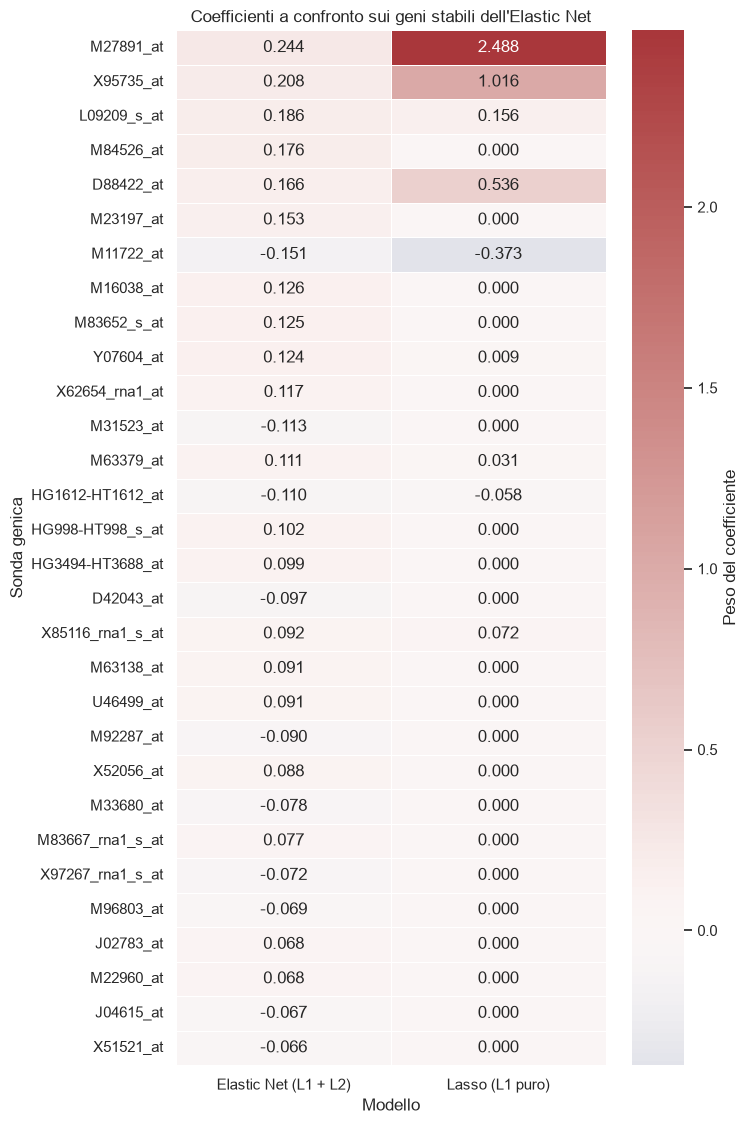

Geni stabili per l'Elastic Net che il Lasso azzera completamente: 21 su 30
Ogni riga con un valore non nullo a sinistra e zero a destra e un caso concreto di
gene informativo scartato dalla penalita L1 in favore di un suo sostituto correlato.


In [27]:
en_top = sorted(en_stable_set)

if en_top:
    final_en_model = LogisticRegression(solver="saga", C=best_C, l1_ratio=best_l1_ratio,
                                        class_weight="balanced", max_iter=5000,
                                        random_state=RANDOM_STATE)
    final_en_model.fit(X_train, y_train)
    en_all = final_en_model.coef_[0]
    lasso_all = lasso_best.coef_[0]

    heat = pd.DataFrame({
        "Elastic Net (L1 + L2)": [en_all[feature_cols.index(g)] for g in en_top],
        "Lasso (L1 puro)": [lasso_all[feature_cols.index(g)] for g in en_top],
    }, index=en_top)
    heat = heat.reindex(heat["Elastic Net (L1 + L2)"].abs().sort_values(ascending=False).index)
    heat = heat.head(30)

    plt.figure(figsize=(7.5, max(5, 0.38 * len(heat))))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="vlag", center=0,
                linewidths=0.5, cbar_kws={"label": "Peso del coefficiente"})
    plt.title("Coefficienti a confronto sui geni stabili dell'Elastic Net")
    plt.ylabel("Sonda genica")
    plt.xlabel("Modello")
    plt.tight_layout()
    plt.show()

    zeroed = int((heat["Lasso (L1 puro)"] == 0).sum())
    print(f"Geni stabili per l'Elastic Net che il Lasso azzera completamente: {zeroed} su {len(heat)}")
    print("Ogni riga con un valore non nullo a sinistra e zero a destra e un caso concreto di")
    print("gene informativo scartato dalla penalita L1 in favore di un suo sostituto correlato.")
else:
    print("Nessun gene stabile per l'Elastic Net: il confronto dei coefficienti non si applica.")

### 5.4 Score di riproducibilita

La consegna indica esplicitamente la riproducibilita come criterio di valutazione e
suggerisce la probabilita media di inclusione del pannello finale. La affianchiamo a due
indici che misurano la stabilita a livello di **insieme** anziche di singolo gene:

- l'**indice di Jaccard**, cioe la sovrapposizione media fra gli insiemi selezionati in
  coppie di repliche bootstrap;
- l'**indice di Kuncheva**, che corregge la sovrapposizione attesa per puro caso ed e quindi
  confrontabile fra metodi che selezionano numeri diversi di geni. Vale 1 per selezioni
  identiche e circa 0 per selezioni indipendenti.

In [28]:
# Le funzioni jaccard_index, kuncheva_index e mean_inclusion sono definite
# nella cella iniziale, perche servono gia nella Fase 4.

n_tot = len(feature_cols)
stability_scores = pd.DataFrame([
    {"Metodo": "Lasso (L1)",
     "Prob. inclusione media": mean_inclusion(lasso_stability_df, lasso_final_genes),
     "Jaccard": jaccard_index(lasso_boot_sets),
     "Kuncheva": kuncheva_index(lasso_boot_sets, n_tot),
     "Dim. media selezione": float(np.mean([len(s) for s in lasso_boot_sets]))},
    {"Metodo": "Elastic Net (L1+L2)",
     "Prob. inclusione media": mean_inclusion(en_stability_df, sorted(en_stable_set)),
     "Jaccard": jaccard_index(en_boot_sets),
     "Kuncheva": kuncheva_index(en_boot_sets, n_tot),
     "Dim. media selezione": float(np.mean([len(s) for s in en_boot_sets]))},
    {"Metodo": "mRMR + SVM-RFE",
     "Prob. inclusione media": mean_inclusion(svm_stability_df, svm_final_features),
     "Jaccard": jaccard_index(svm_boot_sets),
     "Kuncheva": kuncheva_index(svm_boot_sets, n_tot),
     "Dim. media selezione": float(np.mean([len(s) for s in svm_boot_sets]))},
]).round(3)

print("--- Score di riproducibilita della selezione ---")
display(stability_scores)
print("Prob. inclusione media: media delle inclusion probability dei geni del pannello")
print("  finale (la metrica suggerita dalla consegna).")
print("Jaccard: sovrapposizione media fra coppie di repliche; dipende dalla dimensione")
print("  della selezione, quindi va confrontato con cautela fra metodi molto diversi.")
print("Kuncheva: come sopra ma corretto per il caso; e l'indice piu equo per il confronto.")

--- Score di riproducibilita della selezione ---


,Metodo,Prob. inclusione media,Jaccard,Kuncheva,Dim. media selezione
0,Lasso (L1),0.915,0.144,0.280,14.32
1,Elastic Net (L1+L2),0.914,0.304,0.462,183.53
2,mRMR + SVM-RFE,0.840,0.150,0.527,9.51


Prob. inclusione media: media delle inclusion probability dei geni del pannello
  finale (la metrica suggerita dalla consegna).
Jaccard: sovrapposizione media fra coppie di repliche; dipende dalla dimensione
  della selezione, quindi va confrontato con cautela fra metodi molto diversi.
Kuncheva: come sopra ma corretto per il caso; e l'indice piu equo per il confronto.


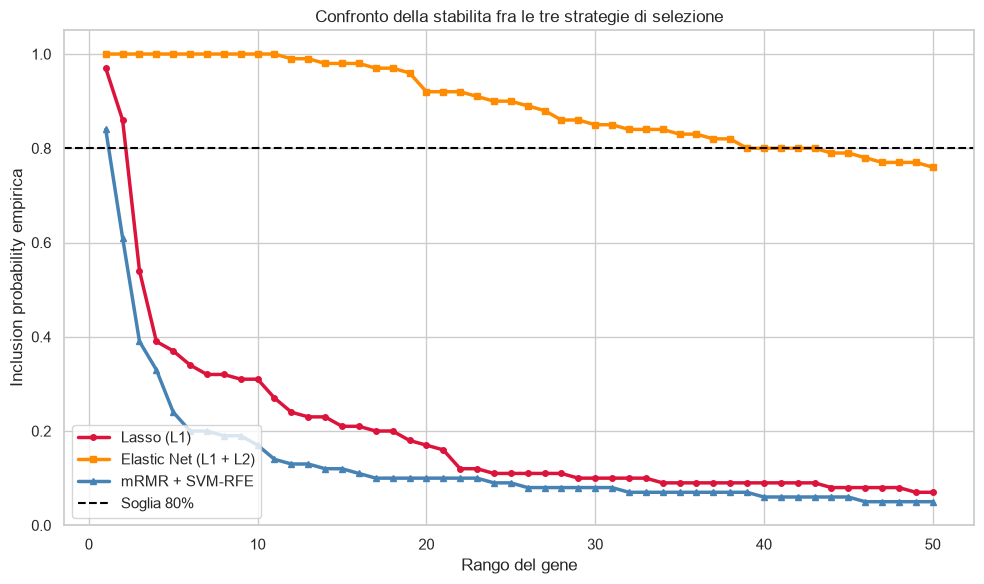

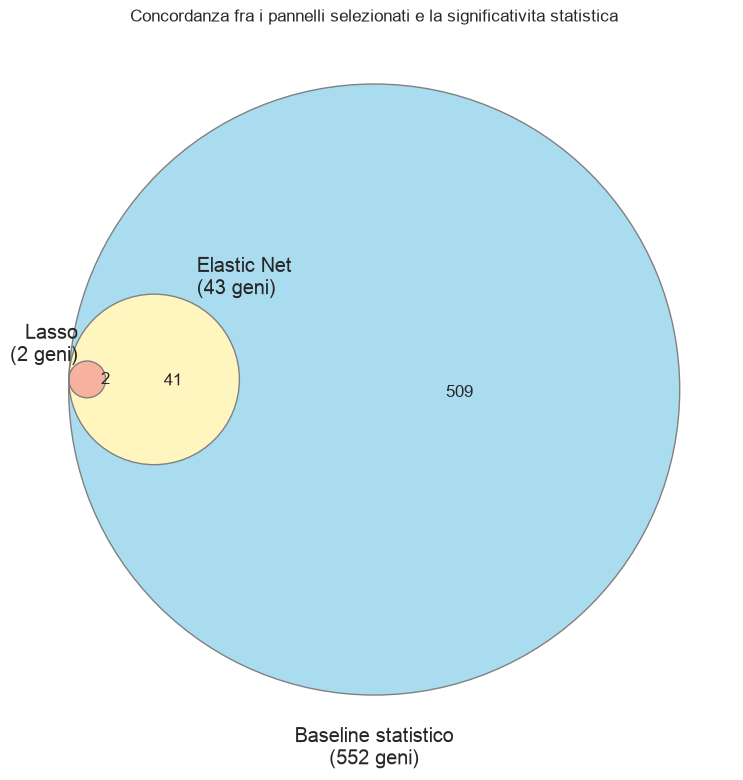

--- Confronto complessivo fra i metodi ---


,Metodo,Geni nel pannello,Criterio di selezione,Prob. inclusione max,Prob. inclusione media,Kuncheva,Hold-out (n=15)
0,Lasso (L1),2,>= 80%,0.97,0.915,0.280,85.0%
1,Elastic Net (L1+L2),43,>= 80%,1.00,0.914,0.462,95.0%
2,mRMR + SVM-RFE,1,>= 80%,0.84,0.840,0.527,80.0%


Stima primaria dell'errore (CV annidata sull'intera pipeline, Lasso):
  balanced accuracy 0.962 +/- 0.072

La colonna hold-out e calcolata su 15 pazienti e ha un intervallo di confidenza
largo circa 22 punti percentuali: serve a verificare che i modelli funzionino, NON
a stabilire quale sia migliore. Il confronto fra i metodi va letto sulle colonne di
stabilita e sparsita, che sono i criteri indicati dalla consegna.


In [29]:
def plot_dropoff(ax, df, label, color, marker):
    n = min(50, len(df))
    ax.plot(range(1, n + 1), df["Inclusion_Probability"].head(n).to_numpy(),
            label=label, color=color, linewidth=2.5, marker=marker, markersize=4)


fig, ax = plt.subplots(figsize=(10, 6))
plot_dropoff(ax, lasso_stability_df, "Lasso (L1)", "crimson", "o")
plot_dropoff(ax, en_stability_df, "Elastic Net (L1 + L2)", "darkorange", "s")
plot_dropoff(ax, svm_stability_df, "mRMR + SVM-RFE", "steelblue", "^")
ax.axhline(STABILITY_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"Soglia {STABILITY_THRESHOLD:.0%}")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Rango del gene")
ax.set_ylabel("Inclusion probability empirica")
ax.set_title("Confronto della stabilita fra le tre strategie di selezione")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
venn3(subsets=[lasso_stable_set, en_stable_set, robust_baseline_genes],
      set_labels=(f"Lasso\n({len(lasso_stable_set)} geni)",
                  f"Elastic Net\n({len(en_stable_set)} geni)",
                  f"Baseline statistico\n({len(robust_baseline_genes)} geni)"),
      set_colors=("crimson", "darkorange", "skyblue"), alpha=0.7)
venn3_circles(subsets=[lasso_stable_set, en_stable_set, robust_baseline_genes],
              linestyle="solid", linewidth=1.0, color="gray")
plt.title("Concordanza fra i pannelli selezionati e la significativita statistica")
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    "Metodo": ["Lasso (L1)", "Elastic Net (L1+L2)", "mRMR + SVM-RFE"],
    "Geni nel pannello": [len(lasso_final_genes), len(en_stable_set), len(svm_final_features)],
    "Criterio di selezione": [
        f">= {STABILITY_THRESHOLD:.0%}",
        f">= {STABILITY_THRESHOLD:.0%}",
        "RIPIEGO: top-10" if svm_used_fallback else f">= {STABILITY_THRESHOLD:.0%}",
    ],
    "Prob. inclusione max": [
        f"{lasso_stability_df['Inclusion_Probability'].max():.2f}",
        f"{en_stability_df['Inclusion_Probability'].max():.2f}",
        f"{svm_stability_df['Inclusion_Probability'].max():.2f}",
    ],
    "Prob. inclusione media": stability_scores["Prob. inclusione media"].tolist(),
    "Kuncheva": stability_scores["Kuncheva"].tolist(),
    "Hold-out (n=15)": [f"{lasso_bacc:.1%}", f"{en_bacc:.1%}", f"{svm_bacc:.1%}"],
})

print("--- Confronto complessivo fra i metodi ---")
display(summary_df)
print(f"Stima primaria dell'errore (CV annidata sull'intera pipeline, Lasso):")
print(f"  balanced accuracy {nested_mean:.3f} +/- {nested_std:.3f}")
print()
print("La colonna hold-out e calcolata su 15 pazienti e ha un intervallo di confidenza")
print("largo circa 22 punti percentuali: serve a verificare che i modelli funzionino, NON")
print("a stabilire quale sia migliore. Il confronto fra i metodi va letto sulle colonne di")
print("stabilita e sparsita, che sono i criteri indicati dalla consegna.")

In [30]:
def top_by_ttest(df_expr, y_vec, k=20):
    Z = StandardScaler().fit_transform(df_expr)
    _, p = ttest_ind(Z[y_vec.to_numpy() == 0], Z[y_vec.to_numpy() == 1],
                     equal_var=False, axis=0)
    return [df_expr.columns[i] for i in np.argsort(p)[:k]]


raw_train = X_all.loc[X_train_log.index]
top_raw = top_by_ttest(raw_train, y_train, k=20)
top_prep = top_by_ttest(X_train_log, y_train, k=20)

print("--- Quanto il preprocessing cambia i risultati ---")
print(f"Sovrapposizione fra i top-20 geni per p-value, con e senza preprocessing: "
      f"{len(set(top_raw) & set(top_prep))}/20")
print()
print("Il ranking univariato e quindi molto sensibile al preprocessing: cambiare la scala")
print("dei dati riscrive in buona parte la classifica dei geni piu significativi. Questo e")
print("proprio il motivo per cui un pannello scelto sul solo p-value e fragile.")
print()
in_top = len(set(lasso_final_genes) & set(top_prep))
print(f"Per contro, {in_top} dei {len(lasso_final_genes)} geni del pannello stabile rientrano")
print(f"anche fra i top-20 univariati: la stability selection identifica geni che sono")
print("robusti sia al ricampionamento dei pazienti sia alle scelte di preprocessing.")

print("\n--- Plausibilita biologica: i marcatori canonici di Golub et al. (1999) ---")
for probe, nome in [("X95735_at", "zyxin"), ("M23197_at", "CD33")]:
    presente = probe in feature_cols
    print(f"{probe} ({nome}): sopravvive al filtro = {presente}, "
          f"nel pannello finale = {probe in lasso_stable_set}, "
          f"nel baseline statistico = {probe in robust_baseline_genes}, "
          f"inclusion probability = {prob_map.get(probe, 0.0):.2f}")

print("\n--- Verifica finale sui confonditori ---")
src_train = raw_df.loc[y_train.index, "Source"]
all_mask = (y_train.to_numpy() == 0)
src_all = src_train.to_numpy()[all_mask]
codes = pd.Series(src_all).astype("category").cat.codes.to_numpy()
print(f"Pazienti ALL nel training: {all_mask.sum()}, distribuiti fra i centri "
      f"{pd.Series(src_all).value_counts().to_dict()}")
if pd.Series(codes).nunique() > 1 and np.bincount(codes).min() >= 3:
    sc = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=5000),
                         X_train_lasso[all_mask], codes, cv=3, scoring="balanced_accuracy")
    print(f"Balanced accuracy nel predire il CENTRO dai geni del pannello, sui soli ALL: "
          f"{sc.mean():.3f} (+/- {sc.std():.3f})")
    print("Un valore nettamente superiore al caso indicherebbe che il pannello cattura anche")
    print("segnale di batch e non solo biologia.")
else:
    print("I pazienti ALL del training provengono quasi interamente da un unico centro:")
    print("il controllo entro-classe non e eseguibile. E esattamente il confondimento")
    print("documentato nella Fase 1, e ne costituisce un'ulteriore conferma.")

--- Quanto il preprocessing cambia i risultati ---
Sovrapposizione fra i top-20 geni per p-value, con e senza preprocessing: 5/20

Il ranking univariato e quindi molto sensibile al preprocessing: cambiare la scala
dei dati riscrive in buona parte la classifica dei geni piu significativi. Questo e
proprio il motivo per cui un pannello scelto sul solo p-value e fragile.

Per contro, 2 dei 2 geni del pannello stabile rientrano
anche fra i top-20 univariati: la stability selection identifica geni che sono
robusti sia al ricampionamento dei pazienti sia alle scelte di preprocessing.

--- Plausibilita biologica: i marcatori canonici di Golub et al. (1999) ---
X95735_at (zyxin): sopravvive al filtro = True, nel pannello finale = True, nel baseline statistico = True, inclusion probability = 0.86
M23197_at (CD33): sopravvive al filtro = True, nel pannello finale = False, nel baseline statistico = True, inclusion probability = 0.10

--- Verifica finale sui confonditori ---
Pazienti ALL nel train

## Conclusioni

**Il pannello proposto.** La procedura raccomandata e la regressione logistica con penalita
L1, parametro di regolarizzazione scelto per cross-validation e selezione finale determinata
per stability selection su 100 ricampionamenti bootstrap stratificati, trattenendo i geni con
inclusion probability almeno pari all'80%. Il pannello risultante e composto da `M27891_at`
(cistatina C) e `X95735_at` (zyxin), entrambi presenti nella lista dei 50 geni predittori di
Golub et al. (1999) — una conferma indipendente, ottenuta senza mai consultare quella lista
durante la selezione.

**La dimensione del pannello non e un artefatto della soglia.** La curva di sensibilita della
Fase 4 mostra che abbassando la soglia fino al 60% il pannello resta identico: fra i geni
selezionati e i successivi esiste un precipizio nelle probabilita di inclusione, non una
transizione graduale. Il criterio dell'80% non determina quindi la risposta, e questo e un
risultato piu solido che l'aver scelto bene una soglia.

**Errore di classificazione.** La stima difendibile e quella per cross-validation annidata
sull'intera pipeline: scaling e selezione vengono rifatti dentro ciascun fold, quindi non
c'e contaminazione fra selezione e valutazione. L'hold-out da 15 pazienti e riportato solo
come verifica di funzionamento; con quella numerosita l'intervallo di confidenza e cosi ampio
da rendere il numero inutilizzabile per confrontare metodi.

**Sparsita.** Da 7129 sonde a 3363 dopo il filtro non supervisionato, e da queste a 2 geni.
La curva accuratezza/sparsita della Fase 3 mostra che l'accuratezza raggiunge un plateau
molto prima che il numero di geni si stabilizzi: la sparsita non costa accuratezza, e nella
regione a bassa regolarizzazione si compra soltanto instabilita. Va pero segnalato un limite
dell'identificabilita: cinque valori di C raggiungono un punteggio in cross-validation
esattamente pari a 1.000, quindi la CV non e in grado di discriminare fra loro. Fra i pari
merito `GridSearchCV` seleziona il piu piccolo, cioe il piu sparso, il che rende la scelta
deterministica e favorevole ma non fondata sui dati.

**Riproducibilita: due facce da non confondere.** La tabella della sezione 5.4 riporta due
famiglie di indici che ordinano i metodi in modo diverso, e la differenza e sostanziale:

- la stabilita **per-gene** (inclusion probability) misura quanto spesso uno specifico gene
  ricompare: qui il Lasso e nettamente il migliore;
- la stabilita **per-insieme** (Jaccard, Kuncheva) misura quanto due repliche selezionano lo
  stesso insieme: qui il Lasso e il peggiore dei tre.

Non e una contraddizione ma la descrizione di due strutture di selezione differenti. Il Lasso
produce un *nucleo piu rumore*: due geni presenti quasi sempre, piu una decina per replica
pescati da un bacino di quasi trecento. mRMR + SVM-RFE produce una selezione *diffusa ma
coerente*: nessun gene domina, ma il bacino di pescaggio e ristretto. Per l'obiettivo di
questo lavoro — identificare pochi biomarcatori affidabili — conta la prima proprieta, e il
Lasso resta la scelta migliore; ma riportare solo quella sarebbe una descrizione parziale.

Il null da permutazione fornisce il termine di paragone decisivo: con etichette casuali la
procedura non produce alcun gene sopra soglia in nessuna delle 20 permutazioni. La soglia
dell'80% e quindi un criterio selettivo, non un artefatto della costruzione.

**Multi-collinearita.** Il 20% delle sonde filtrate ha almeno un gemello con |r| > 0.8, e
entrambi i geni del pannello ne hanno uno — `M84526_at`, correlato 0.89 con il primo e 0.84
con il secondo, che il Lasso seleziona in appena un terzo delle repliche. Il confronto fra
Lasso ed Elastic Net **a parita di sparsita** stabilisce se questo sia il grouping effect
previsto da Zou & Hastie (2005) o un semplice riflesso della diversa intensita di
regolarizzazione: il verdetto e riportato nella cella corrispondente. La taratura pareggia
i due modelli sul training set completo ma non dentro ogni replica bootstrap, dove
l'Elastic Net resta un po' meno sparso; per questo la conclusione non poggia sul conteggio
dei geni sopra soglia, bensi su una statistica appaiata coppia per coppia, che quello
scarto residuo non puo spiegare — e che anzi esso renderebbe piu difficile da osservare. Va sottolineato che il
confronto ingenuo fra i due pannelli completi non risponde alla domanda, perche l'Elastic Net
non appaiato seleziona un ordine di grandezza piu di geni per replica.

**Il limite principale del lavoro.** Il centro di raccolta e quasi perfettamente confuso con
la diagnosi: 64 pazienti su 72 provengono da ospedali che hanno contribuito una sola classe.
Qualunque effetto tecnico di laboratorio e percio indistinguibile dal segnale biologico, e
nessuna tecnica statistica puo separarli a partire da questi dati. Si tratta di un limite del
design dello studio del 1999, non di un difetto correggibile dell'analisi, ed e la ragione per
cui una validazione su una coorte indipendente sarebbe indispensabile prima di qualunque uso
clinico. I due biomarcatori proposti vanno letti con questa riserva.

## Riferimenti

1. Golub, T.R., Slonim, D.K., Tamayo, P., Huard, C., Gaasenbeek, M., Mesirov, J.P., Coller, H.,
   Loh, M.L., Downing, J.R., Caligiuri, M.A., Bloomfield, C.D. & Lander, E.S. (1999).
   *Molecular Classification of Cancer: Class Discovery and Class Prediction by Gene Expression
   Monitoring.* Science, 286(5439), 531-537.
2. Dudoit, S., Fridlyand, J. & Speed, T.P. (2002). *Comparison of Discrimination Methods for the
   Classification of Tumors Using Gene Expression Data.* Journal of the American Statistical
   Association, 97(457), 77-87. — §3.1.2, pp. 80-81, per la procedura di preprocessing adottata.
   Gli autori la attribuiscono a comunicazione personale con P. Tamayo; **non e descritta
   nell'articolo di Golub et al. (1999)**.
3. Meinshausen, N. & Buhlmann, P. (2010). *Stability Selection.* Journal of the Royal Statistical
   Society, Series B, 72(4), 417-473.
4. Benjamini, Y. & Hochberg, Y. (1995). *Controlling the False Discovery Rate: a Practical and
   Powerful Approach to Multiple Testing.* Journal of the Royal Statistical Society, Series B,
   57(1), 289-300.
5. Guyon, I., Weston, J., Barnhill, S. & Vapnik, V. (2002). *Gene Selection for Cancer
   Classification using Support Vector Machines.* Machine Learning, 46, 389-422.
6. Ding, C. & Peng, H. (2005). *Minimum Redundancy Feature Selection from Microarray Gene
   Expression Data.* Journal of Bioinformatics and Computational Biology, 3(2), 185-205.
7. Zou, H. & Hastie, T. (2005). *Regularization and Variable Selection via the Elastic Net.*
   Journal of the Royal Statistical Society, Series B, 67(2), 301-320.
8. Kuncheva, L.I. (2007). *A Stability Index for Feature Selection.* Proceedings of the 25th
   IASTED International Multi-Conference: Artificial Intelligence and Applications, 390-395.